In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path 
from tqdm import tqdm 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad("../../../../../project_folder/data/gdrive/dataset_unmix8/ds_HID01_logicle_100k_UMAP_ann.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

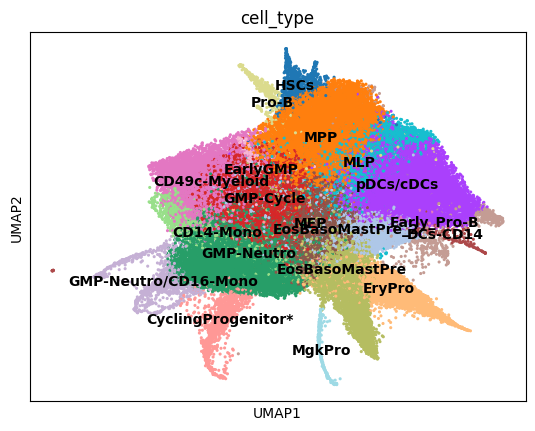

In [4]:
sc.pl.umap(
    adata,
    color="cell_type",
    s=20,
    legend_loc="on data"
)

In [5]:
adata.obs.cell_type.value_counts()/adata.obs.shape[0]

cell_type
MPP                     0.17135
GMP-Neutro              0.14414
GMP-Cycle               0.13822
pDCs/cDCs               0.13135
MEP                     0.08171
CD49c-Myeloid           0.06629
EosBasoMastPre          0.06474
MLP                     0.05866
EosBasoMastPre_2        0.04403
EryPro                  0.03163
CD14-Mono               0.01766
CyclingProgenitor*      0.01200
GMP-Neutro/CD16-Mono    0.01015
HSCs                    0.00783
Early_Pro-B             0.00658
EarlyGMP                0.00505
Pro-B                   0.00454
MgkPro                  0.00222
DCs-CD14                0.00185
Name: count, dtype: float64

## Check cell type profiles per unique protocol 

In [6]:
adata.obs.columns

Index(['replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id',
       'count_beads', 'cell_counts', 'experiment_number', 'experiment_id',
       '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]',
       'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]',
       'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]',
       'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype',
       'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture',
       'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id',
       'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area',
       'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden',
       'cell_type'],
      dtype='object')

In [7]:
protocol_columns = ["740-yp_[µm]", 
                   "mtg_[µm]", 
                   "rhflt3l_[ng_ml]", 
                   "gm-csf_[ng_ml]", 
                   "tpo_[ng_ml]",
                   "sr1_[nm]", 
                   "um171_[nm]", 
                   "um729_[µm]", 
                   "scf_[ng_ml]",
                   "butyzamide_[nm]",
                   "retinoic_acid_[µm]",
                   "ldl_[ng_ml]", 
                   "il3_[ng_ml]", 
                   "o2_[%]", 
                   "days_of_culture"]

In [8]:
for p in protocol_columns:
    print(p)
    print(np.array(adata.obs[p].unique()))
    print()

740-yp_[µm]
[5]

mtg_[µm]
[100]

rhflt3l_[ng_ml]
[10]

gm-csf_[ng_ml]
['10' '0' '1']

tpo_[ng_ml]
[2.5  0.   0.5  1.   0.25]

sr1_[nm]
[750 375  75   0]

um171_[nm]
[1120.     1.5  280.     0.   560.    70. ]

um729_[µm]
[0.00e+00 1.12e+03 7.50e-01 1.50e+00]

scf_[ng_ml]
[50 10  0]

butyzamide_[nm]
[  0 100]

retinoic_acid_[µm]
[0 1 5]

ldl_[ng_ml]
[ 0  2 50 10  5 20]

il3_[ng_ml]
[ 5.   0.  10.   2.5 20. ]

o2_[%]
[20 10]

days_of_culture
[21 14 27 13 36 15]



In [9]:
# Obs 
cell_type_proportions = {cell_type: [] for cell_type in adata.obs.cell_type.unique()}

# X 
obs_protocols = adata.obs.loc[:, protocol_columns].values.astype(float)
X = np.unique(obs_protocols, axis=0)

In [10]:
# Number of unique protocols 
X.shape

(116, 15)

In [11]:
for unique_protocol in tqdm(X):
    idx = (adata.obs.loc[:, protocol_columns].values.astype(float)==unique_protocol[None, :]).all(1)
    adata_protocol = adata[idx]
    proportions = adata_protocol.obs.cell_type.value_counts() / adata_protocol.shape[0]
    for cell_type in cell_type_proportions: 
        if cell_type in proportions.index.values:
            cell_type_proportions[cell_type].append(proportions[cell_type])
        else:
            cell_type_proportions[cell_type].append(0.0)

100%|██████████| 116/116 [00:09<00:00, 12.85it/s]


In [12]:
proportion_df = pd.DataFrame(cell_type_proportions)

protocol_adata = sc.AnnData(X=np.log1p(X), obs=proportion_df)
protocol_adata.var.index = protocol_columns

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [13]:
argmax_protocols = np.argmax(protocol_adata.obs, axis=0)

In [14]:
adata_argmax = protocol_adata[argmax_protocols]
adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)

/tmp/ipykernel_704255/824891330.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_argmax.obs["cell_type"] = np.array(adata_argmax.obs.columns)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


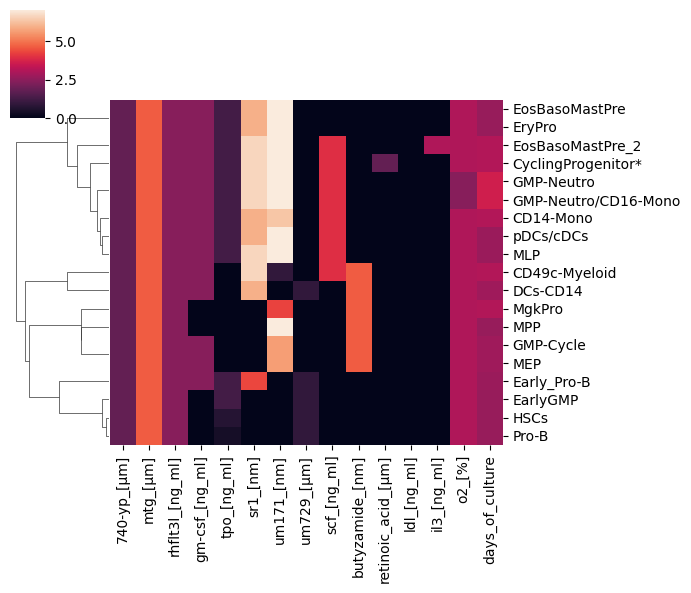

In [15]:
sns.clustermap(
    adata_argmax.X,
    yticklabels=adata_argmax.obs["cell_type"], 
    xticklabels=adata_argmax.var.index, 
    figsize=(7, 6),
    col_cluster=False
)
plt.show()

In [16]:
protocol_adata

AnnData object with n_obs × n_vars = 116 × 15
    obs: 'pDCs/cDCs', 'CyclingProgenitor*', 'EosBasoMastPre_2', 'CD49c-Myeloid', 'MLP', 'GMP-Cycle', 'EosBasoMastPre', 'MEP', 'EryPro', 'MgkPro', 'GMP-Neutro', 'MPP', 'CD14-Mono', 'GMP-Neutro/CD16-Mono', 'EarlyGMP', 'HSCs', 'Early_Pro-B', 'DCs-CD14', 'Pro-B'

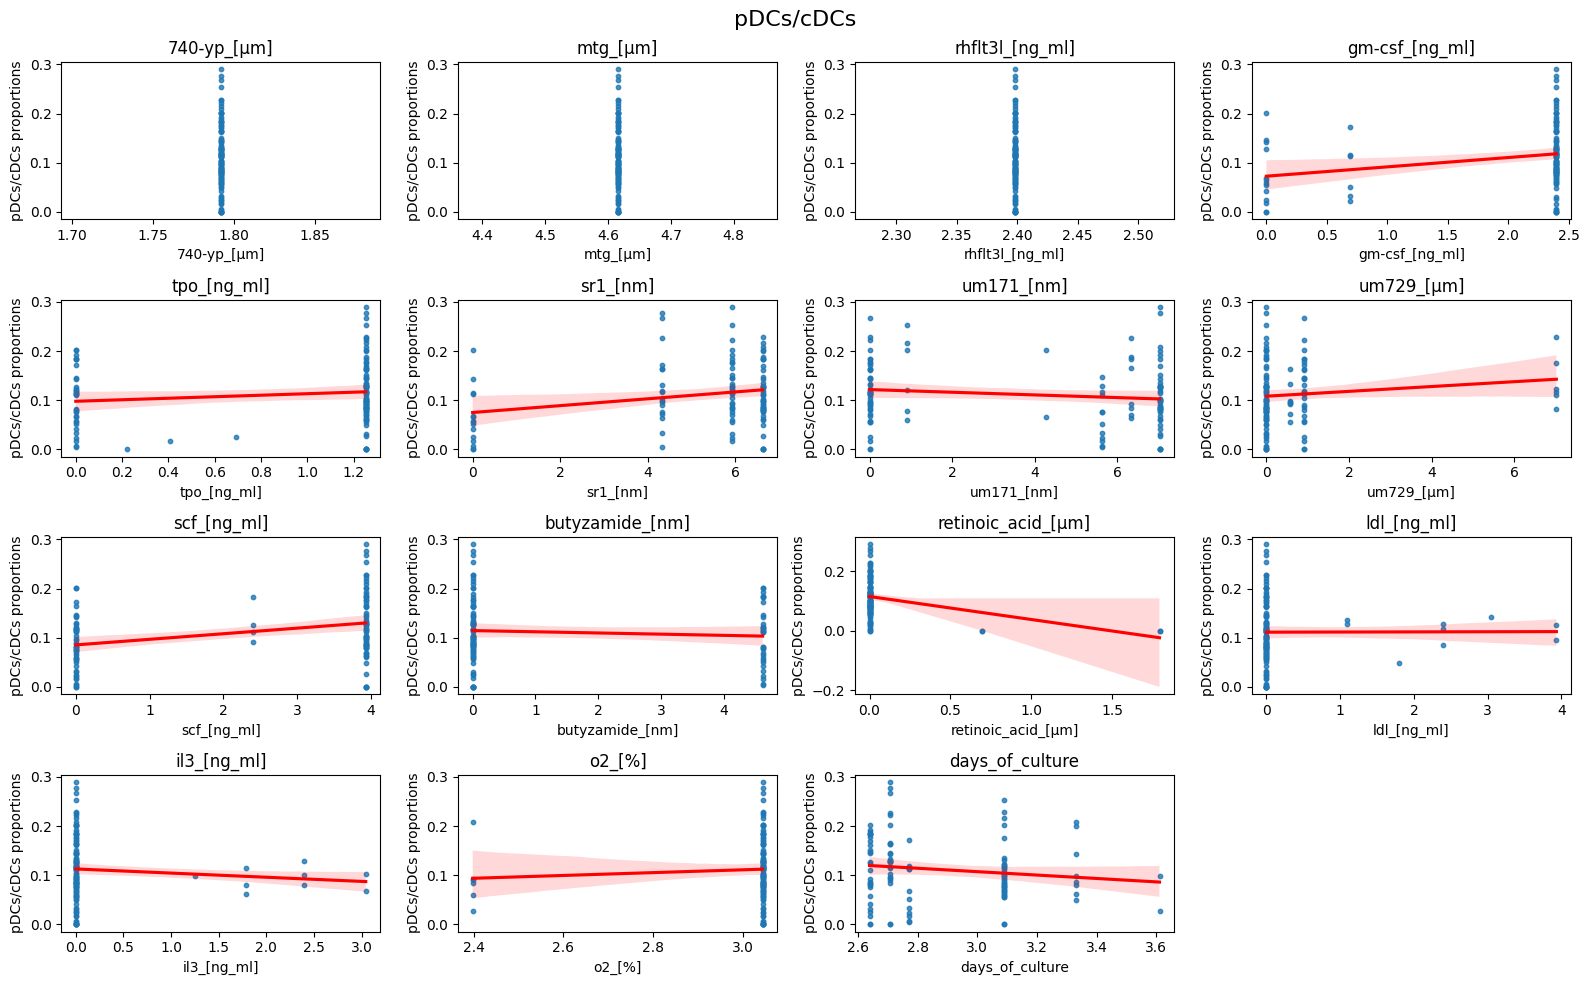

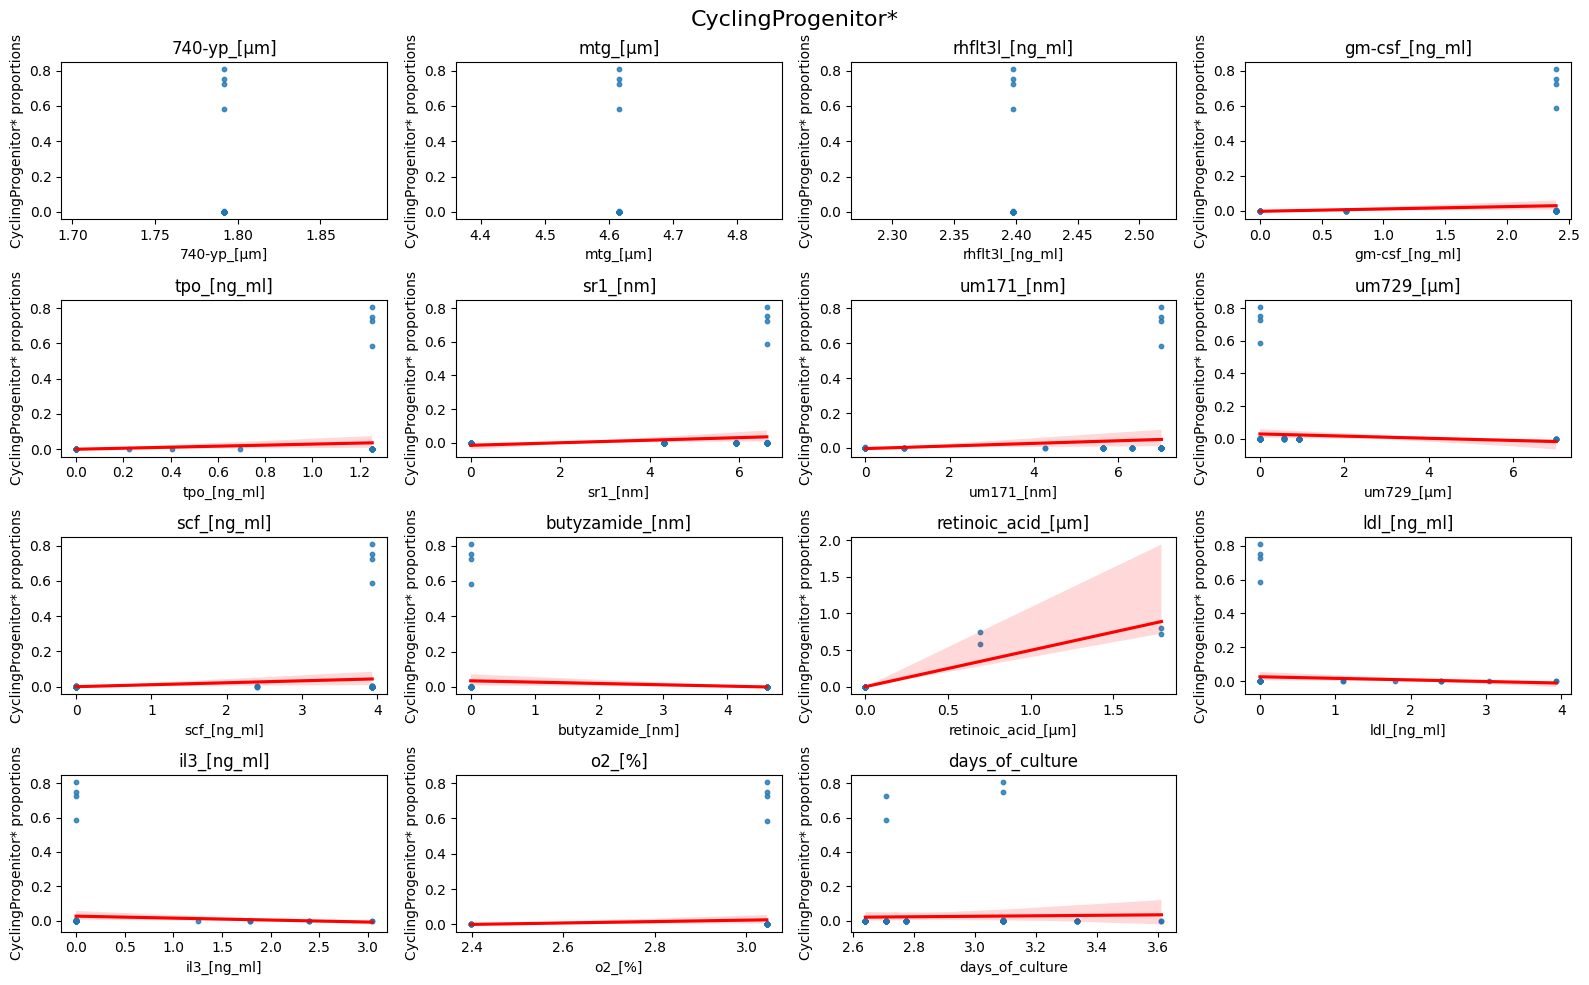

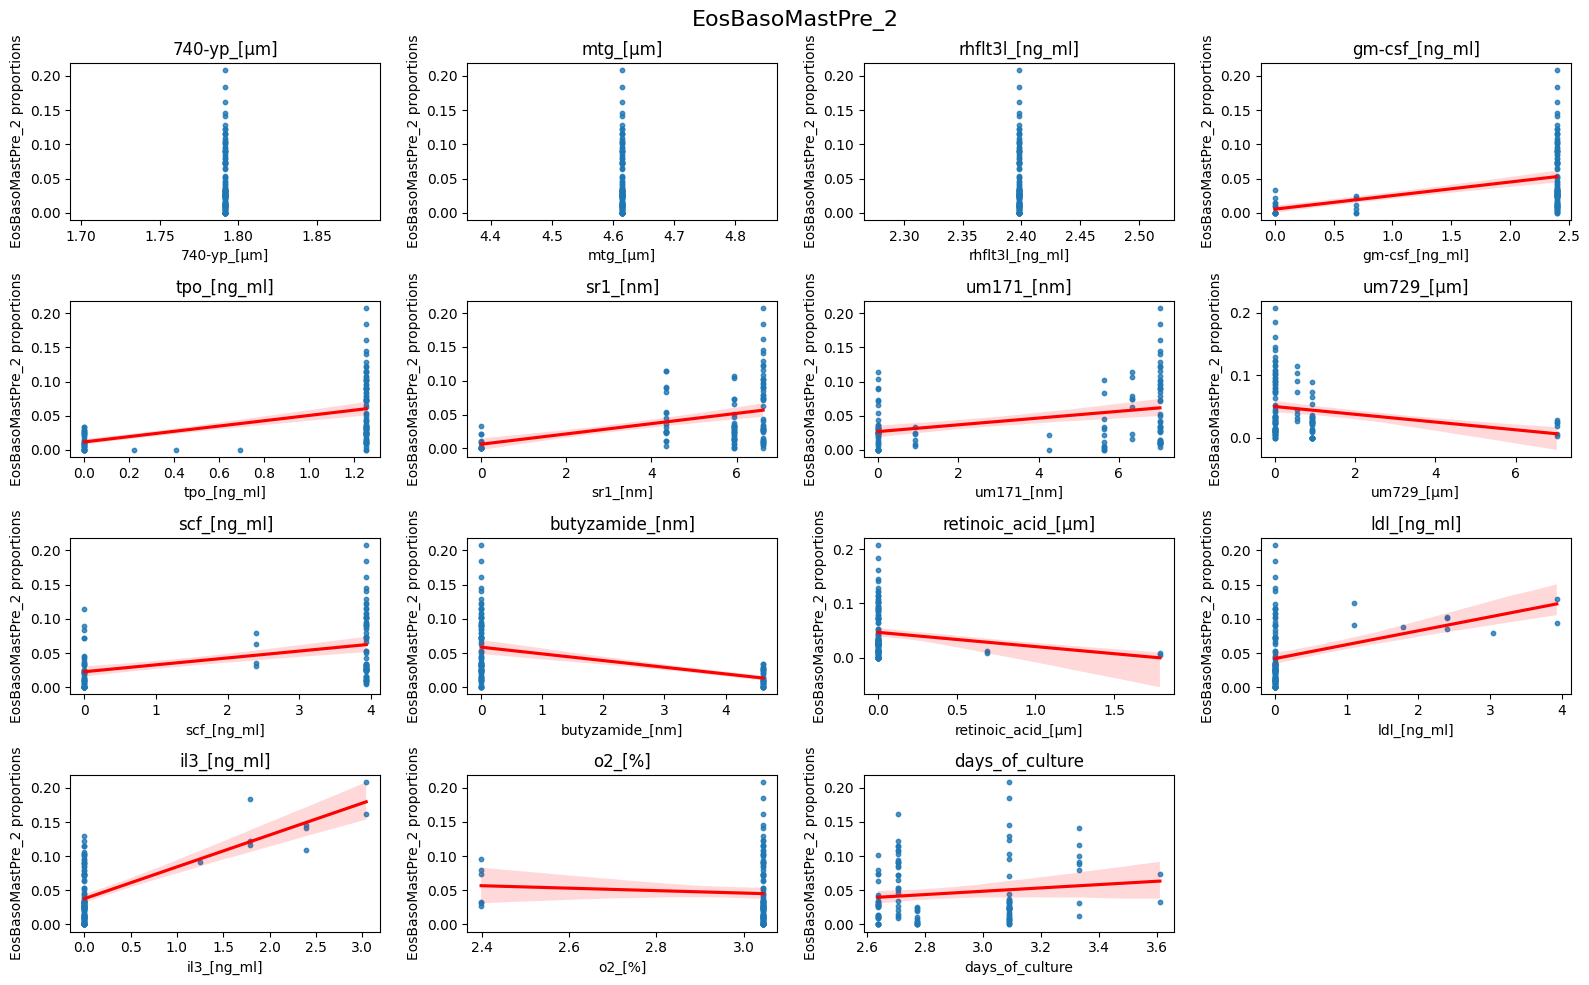

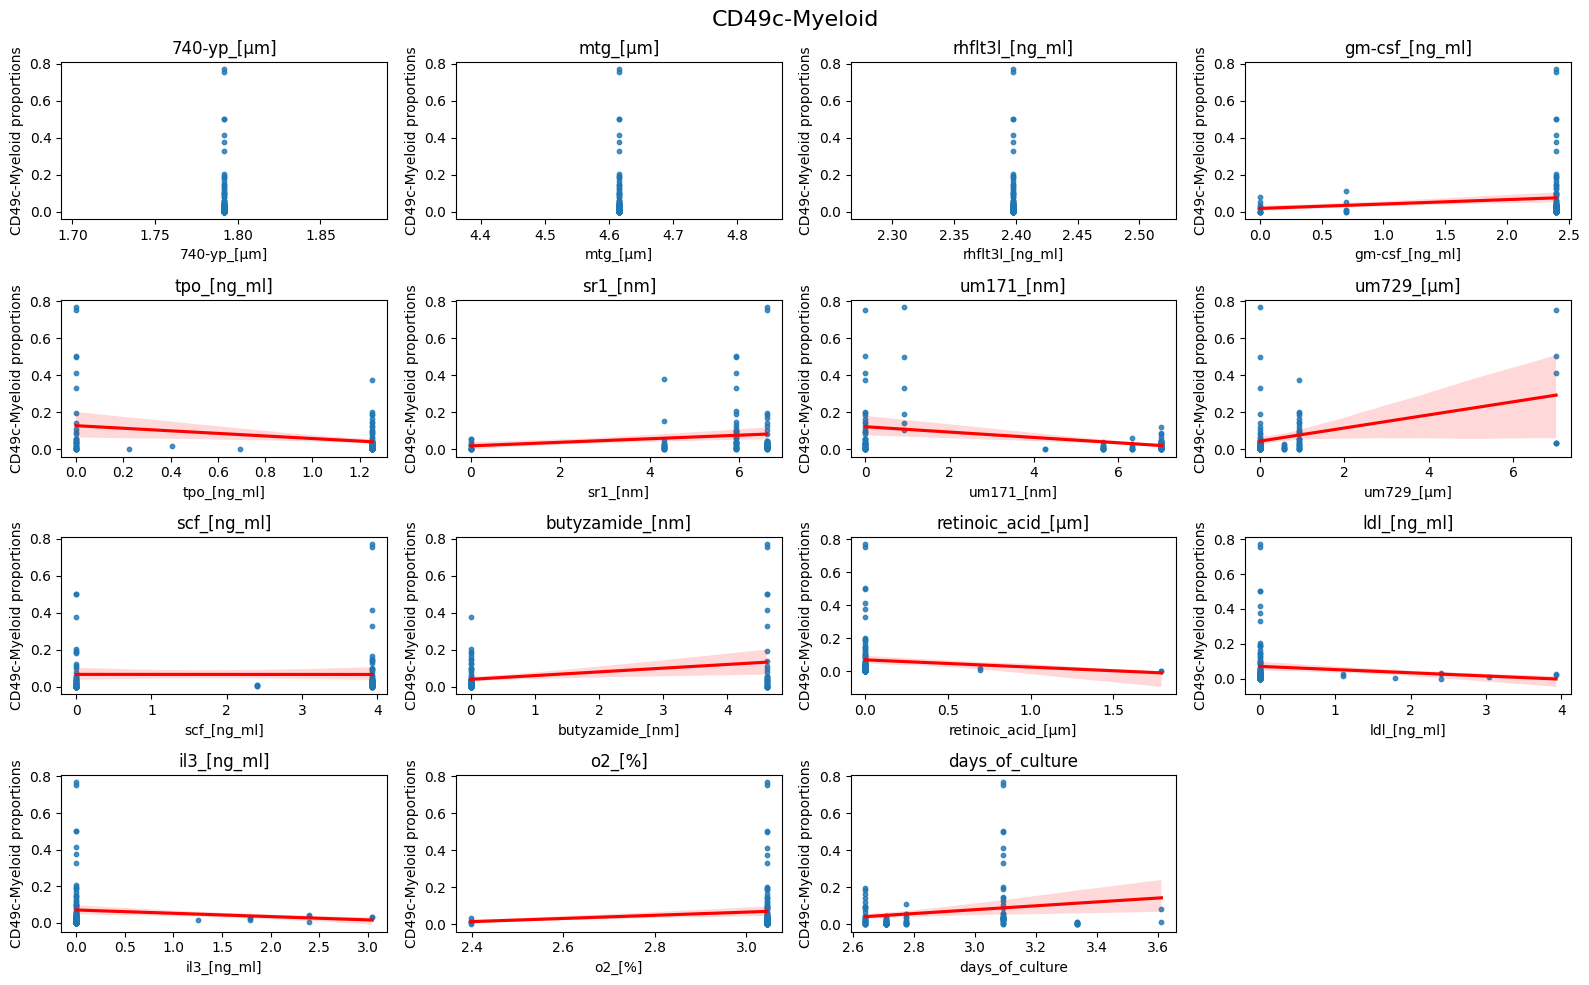

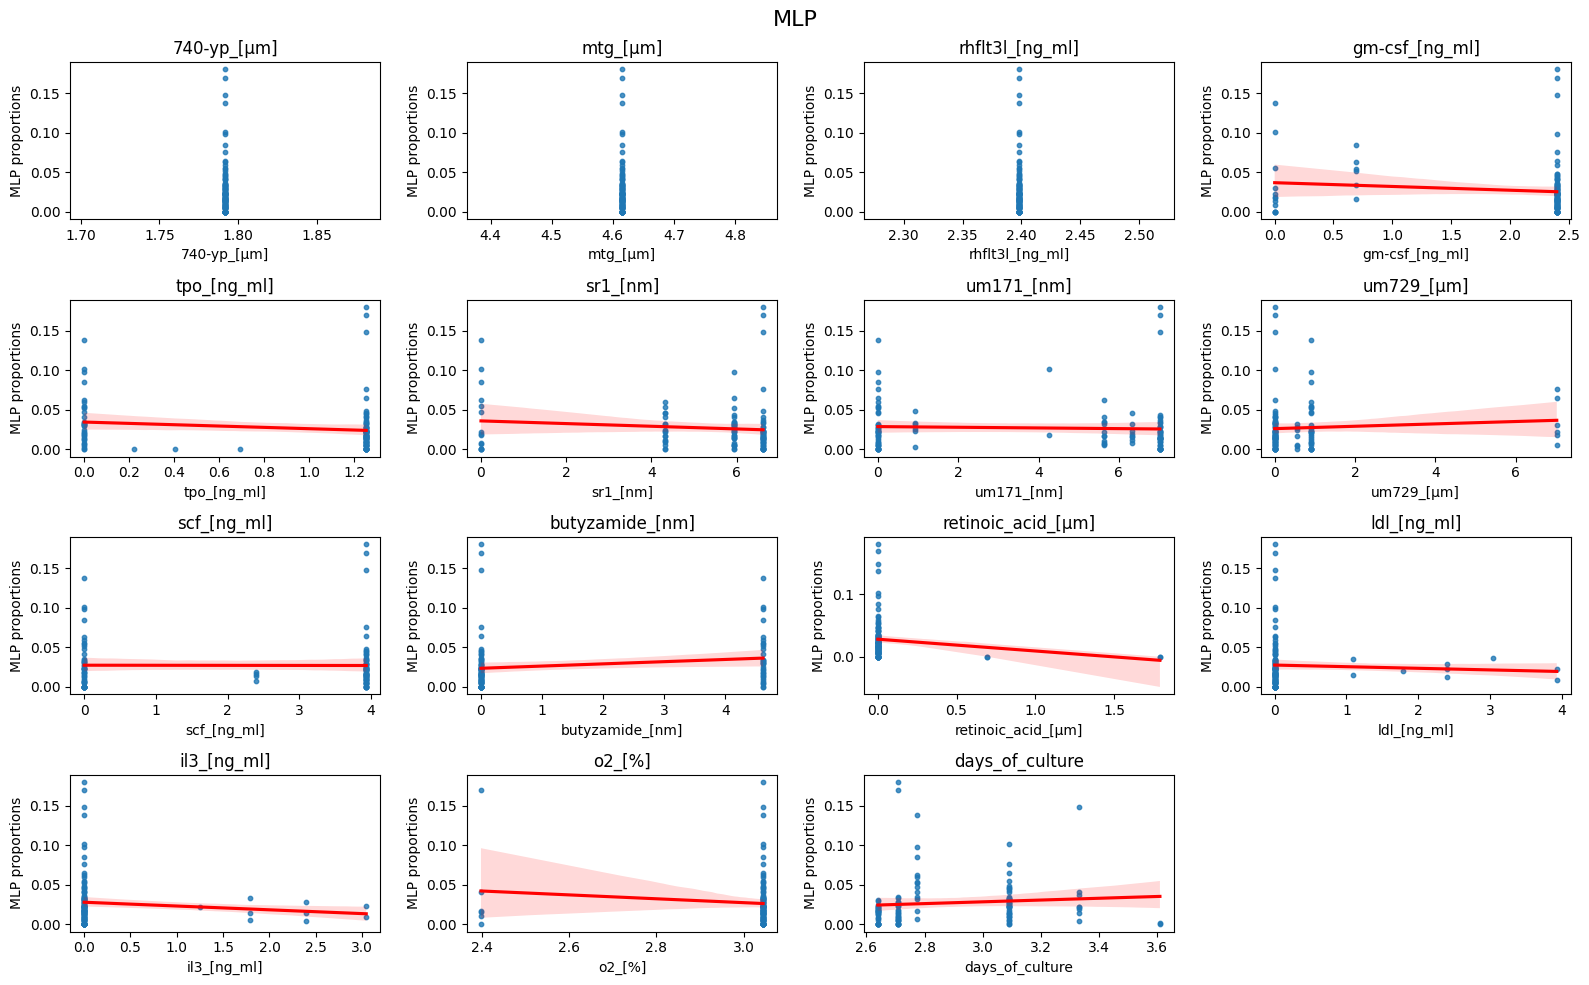

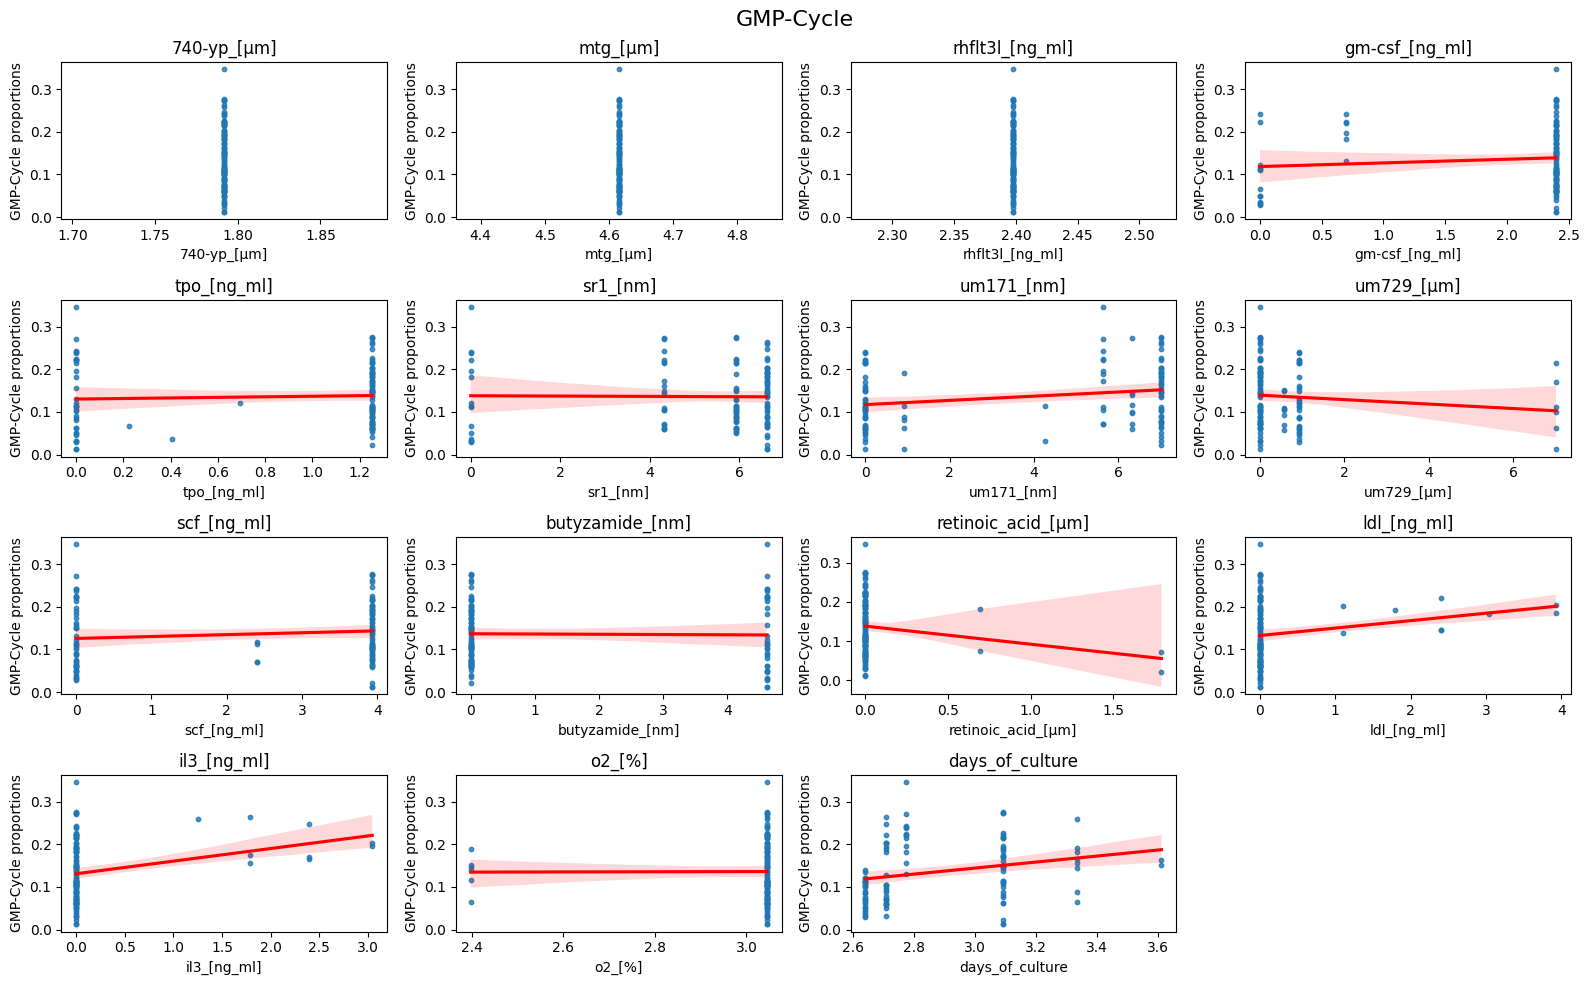

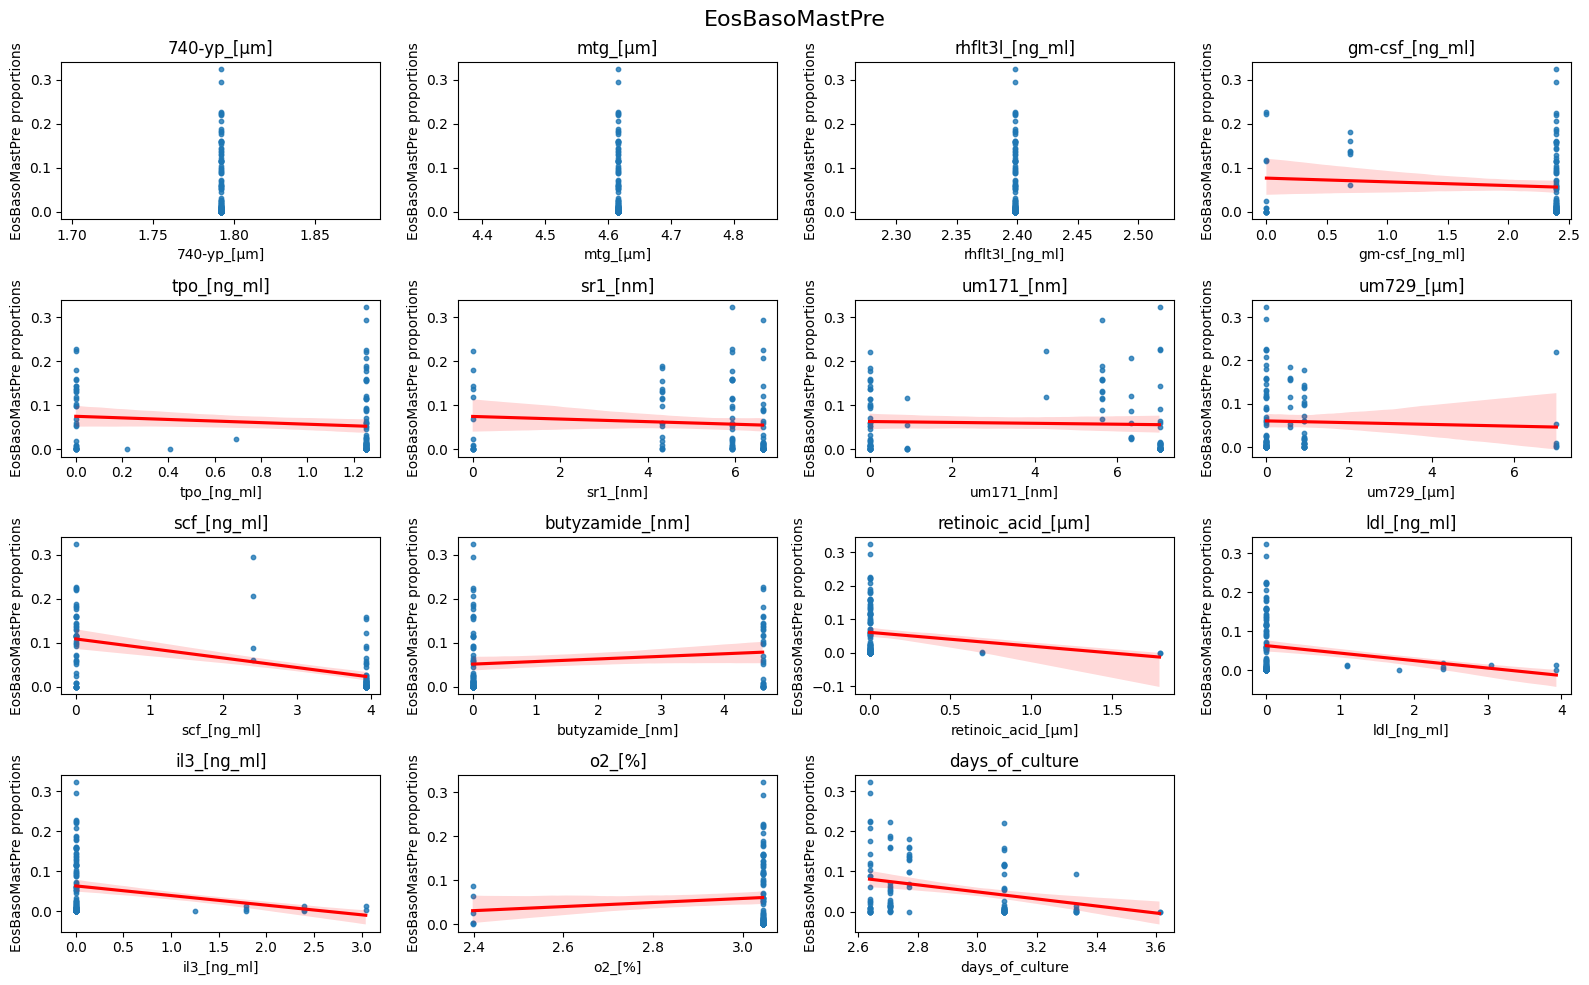

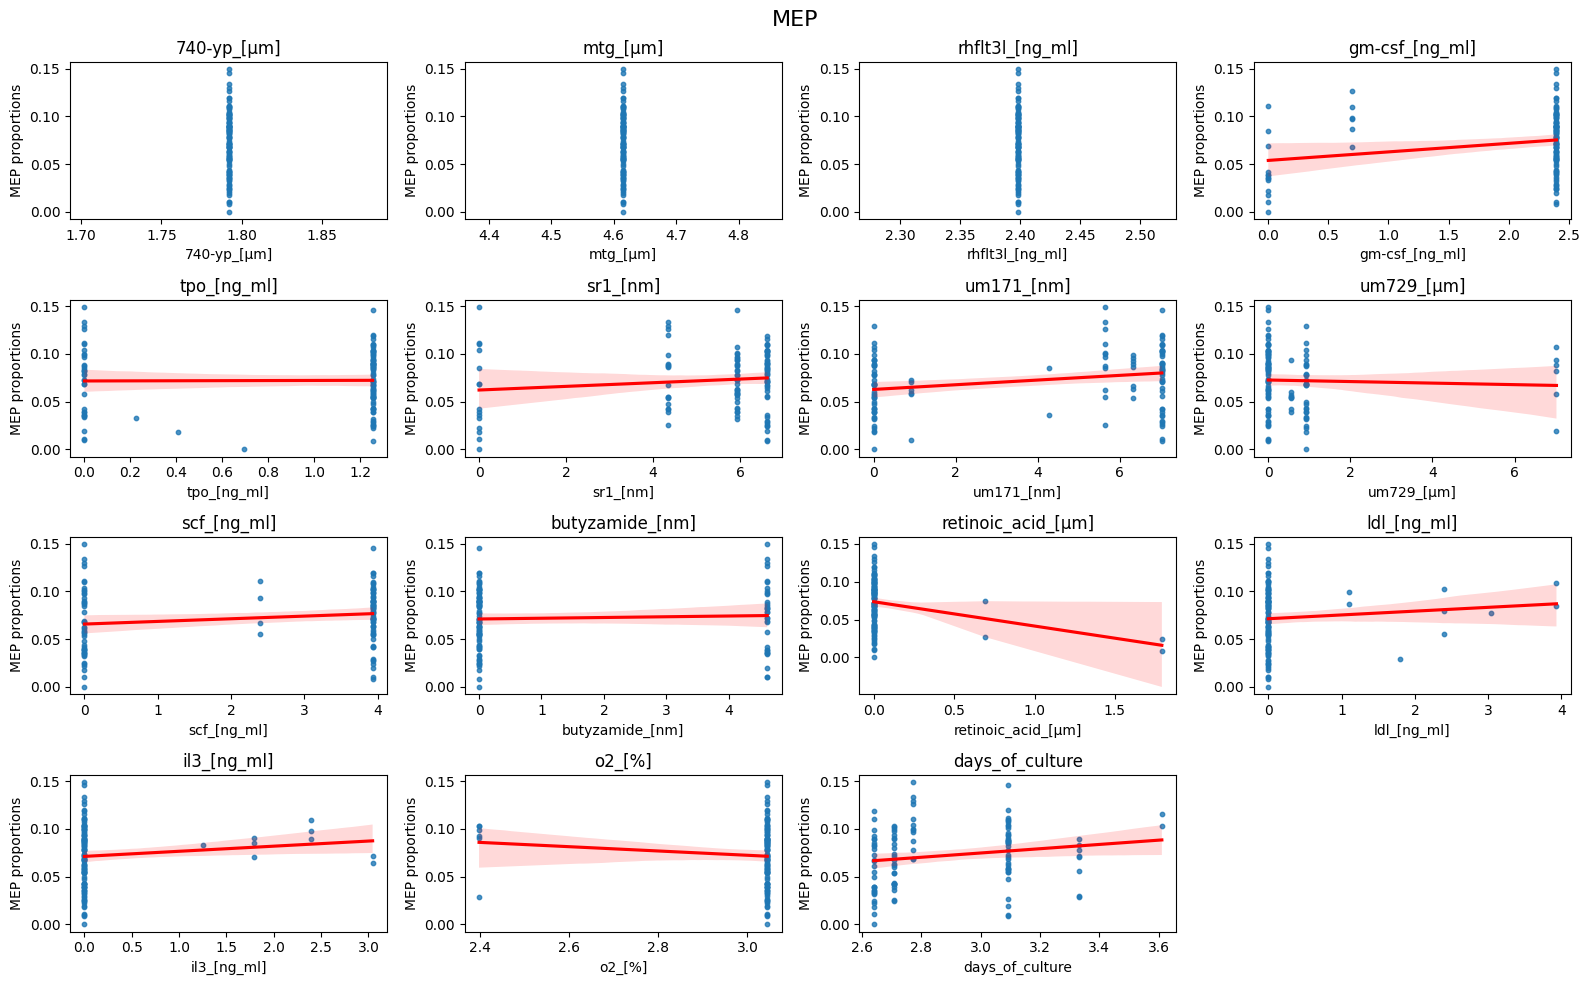

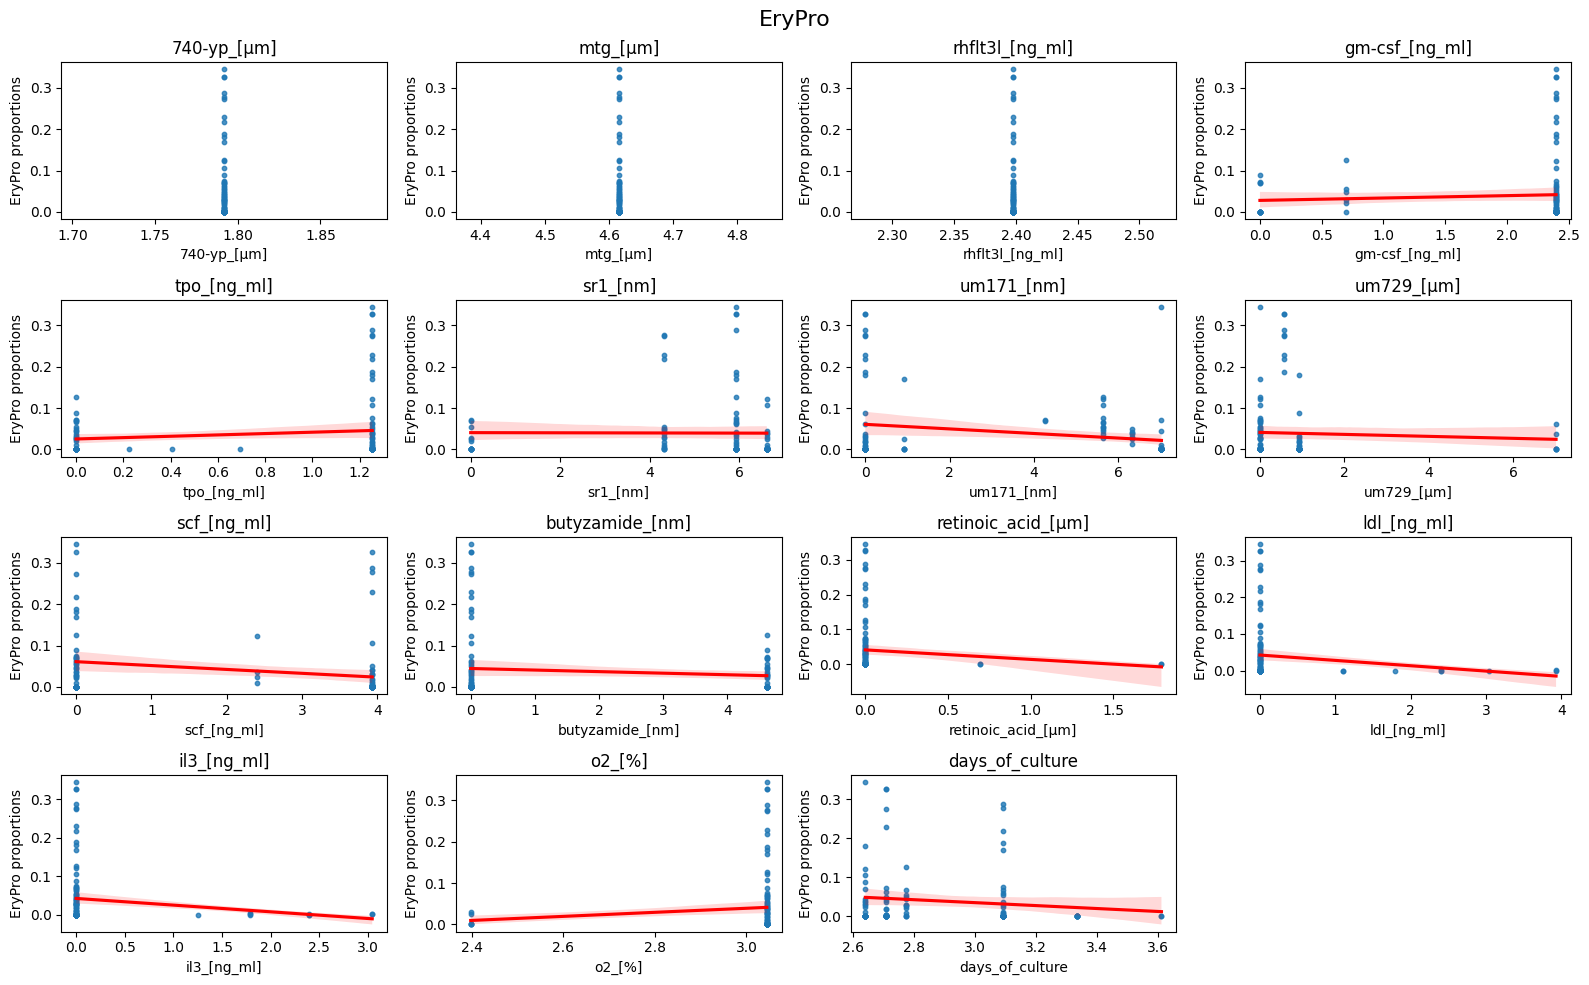

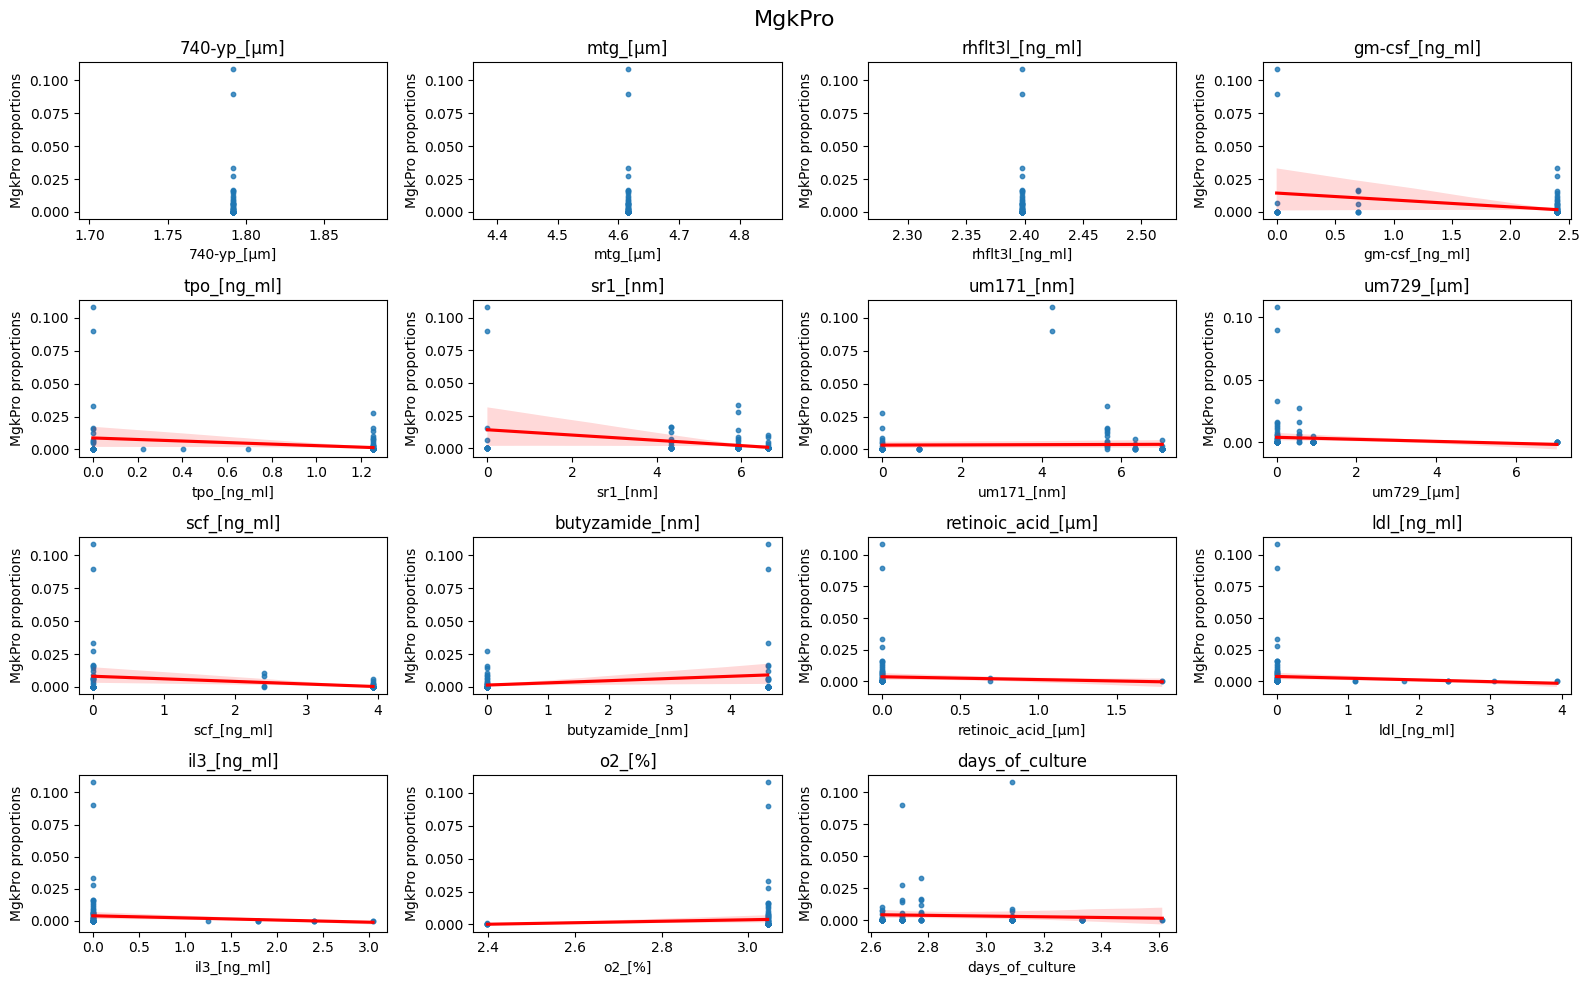

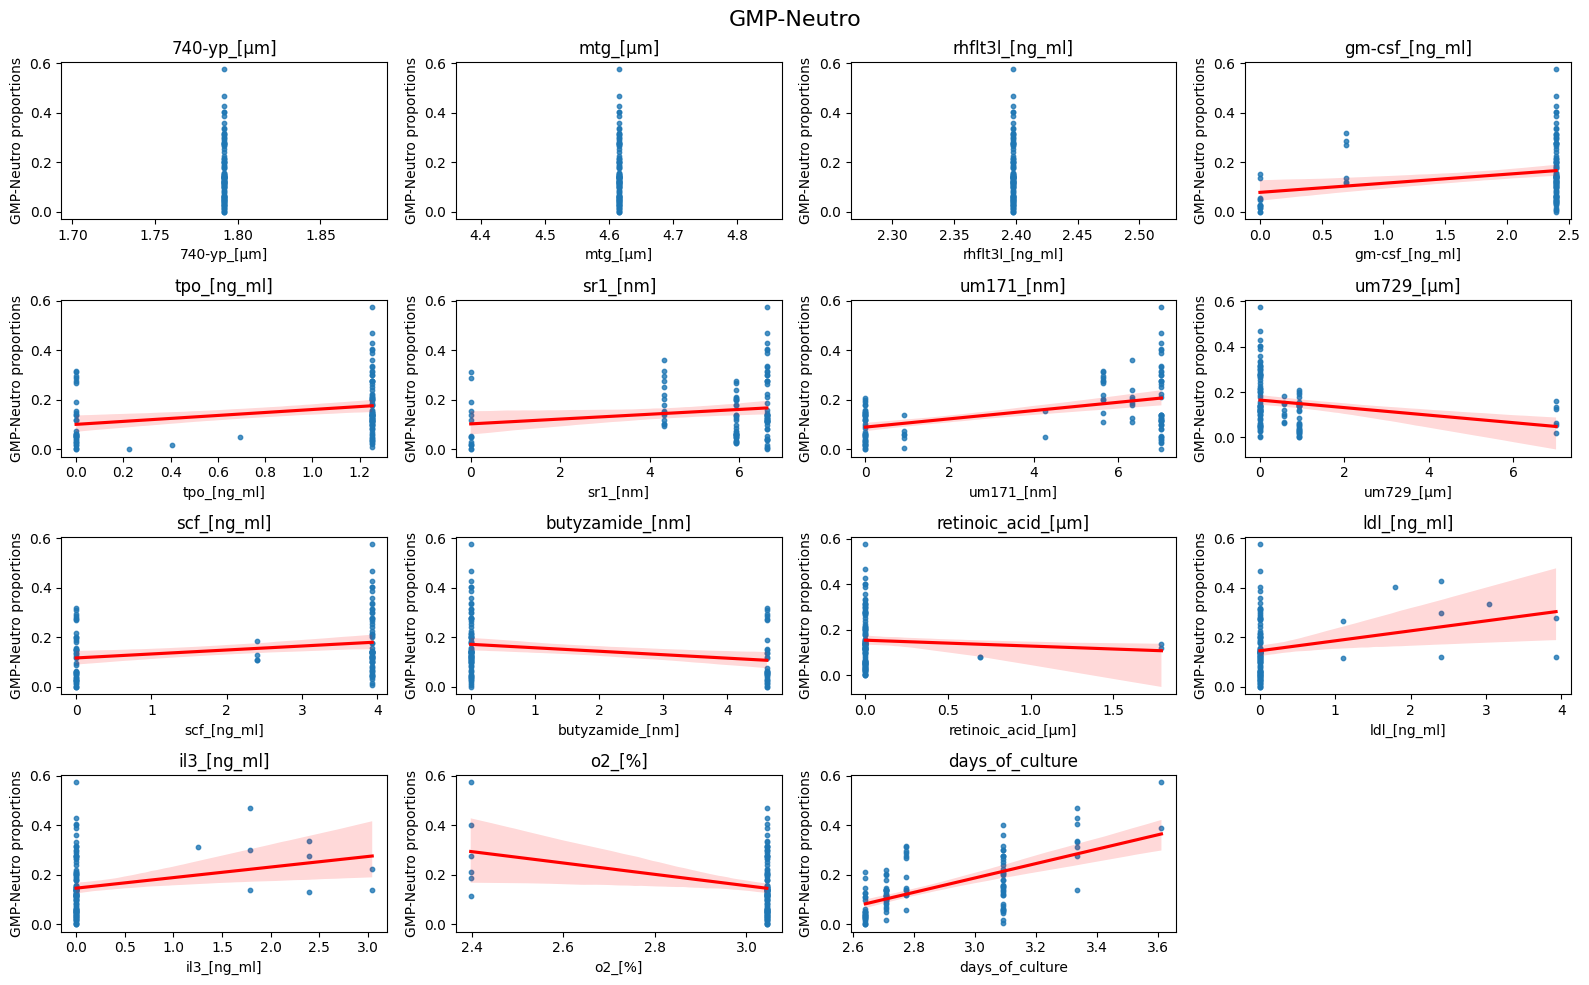

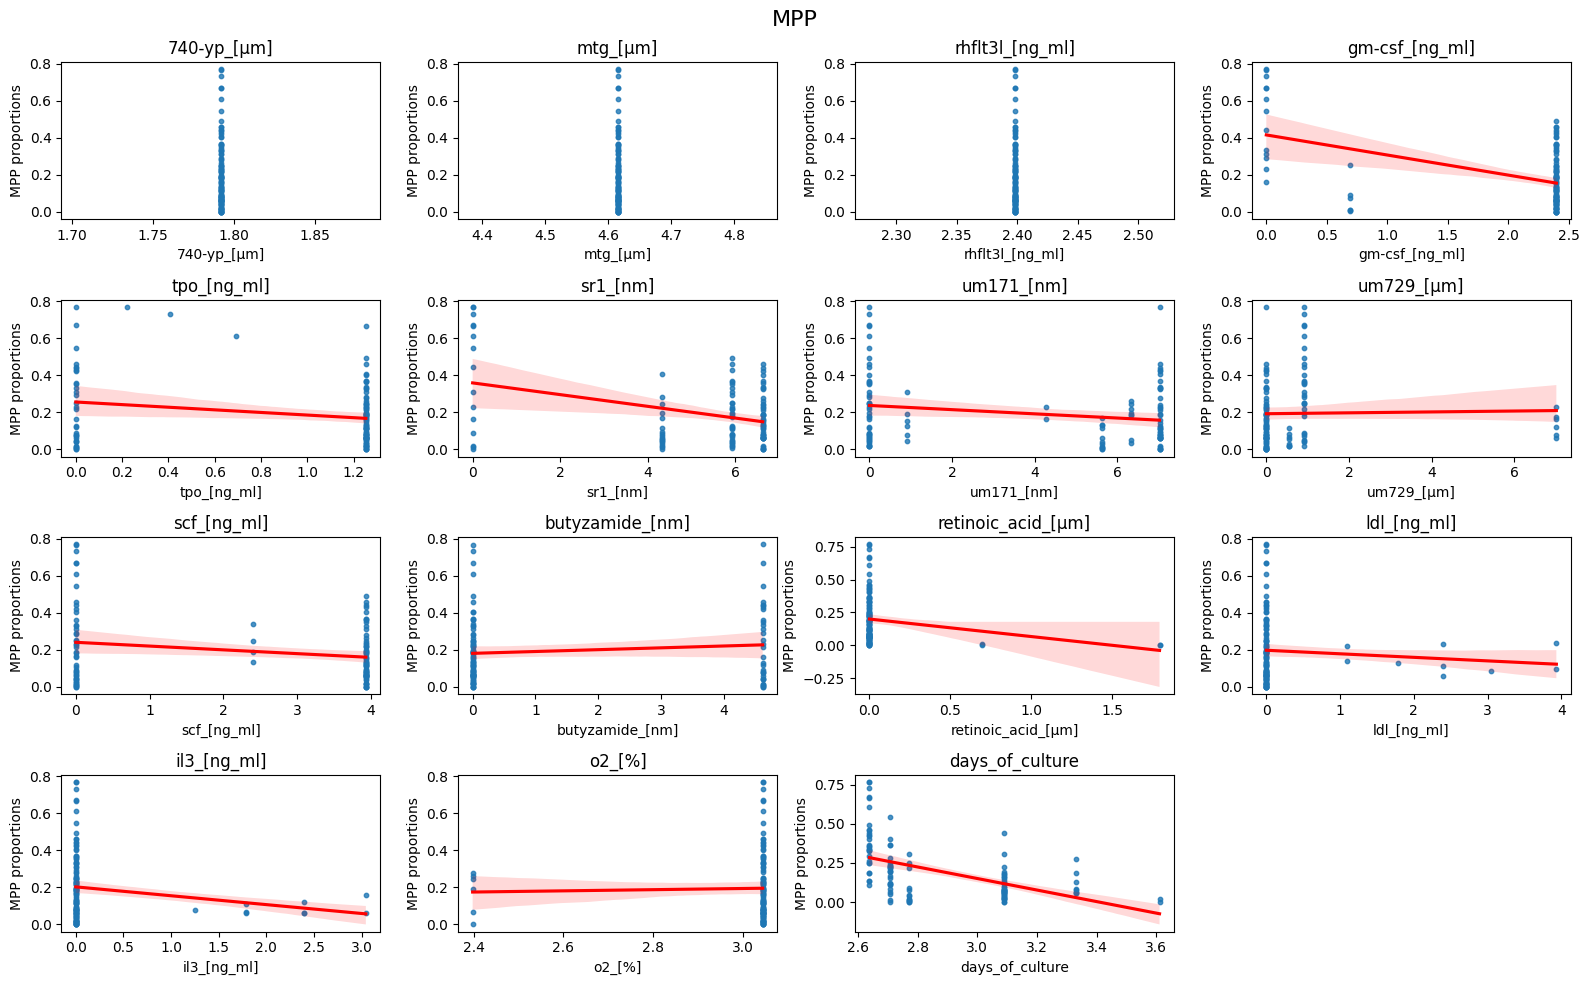

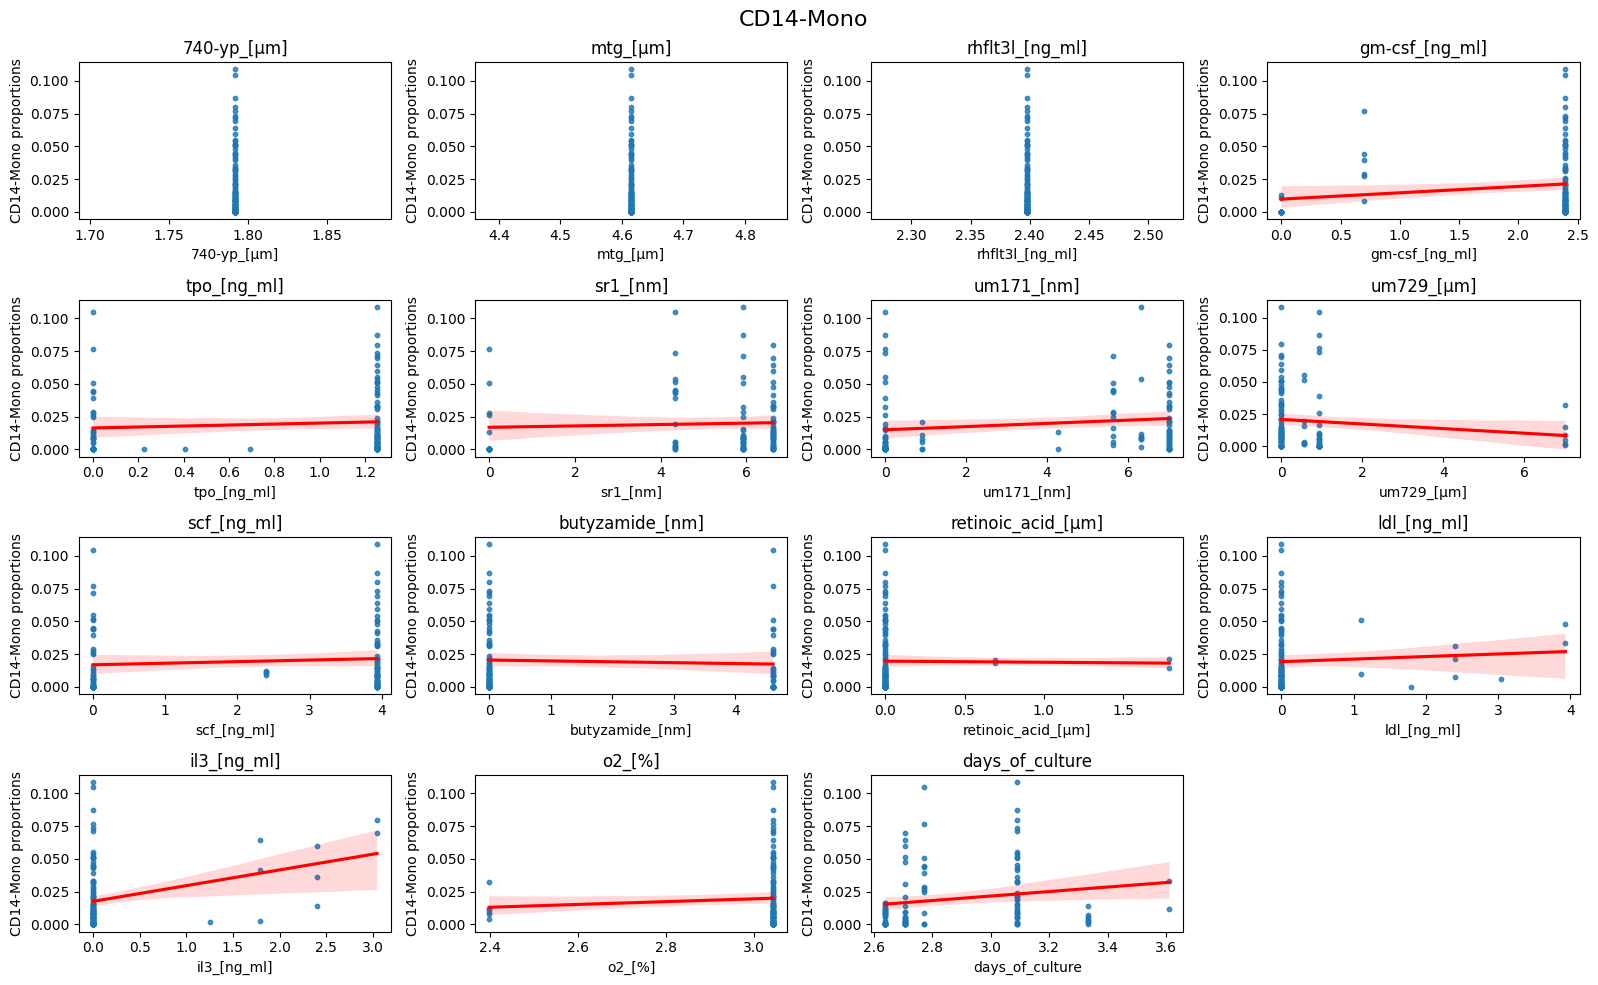

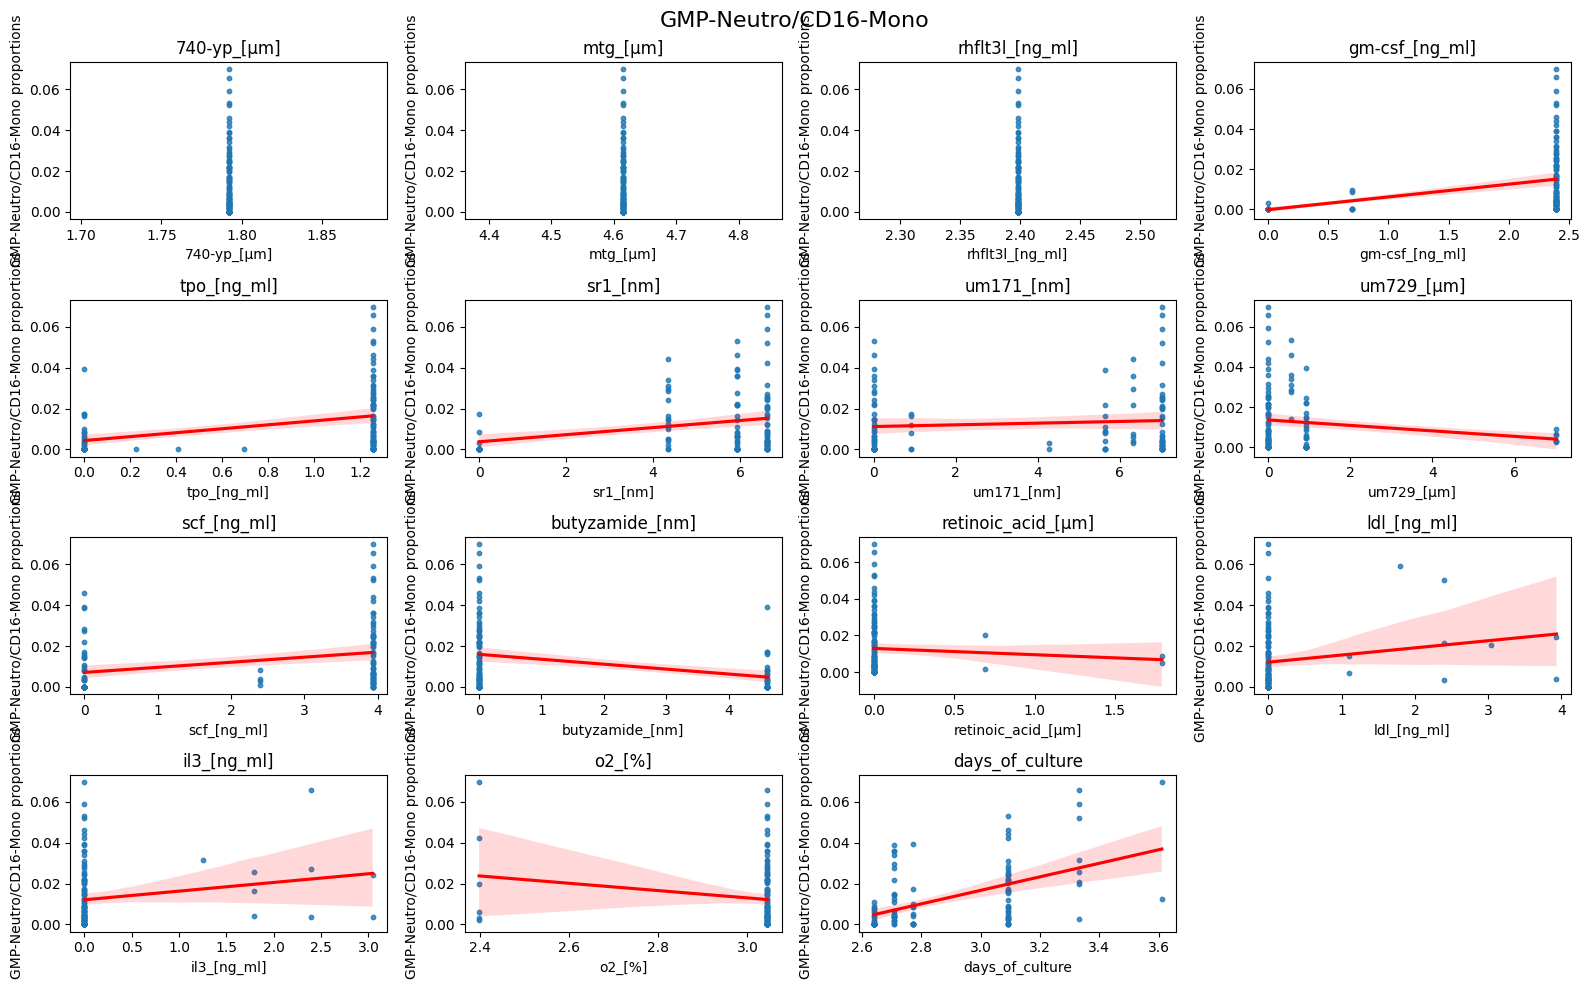

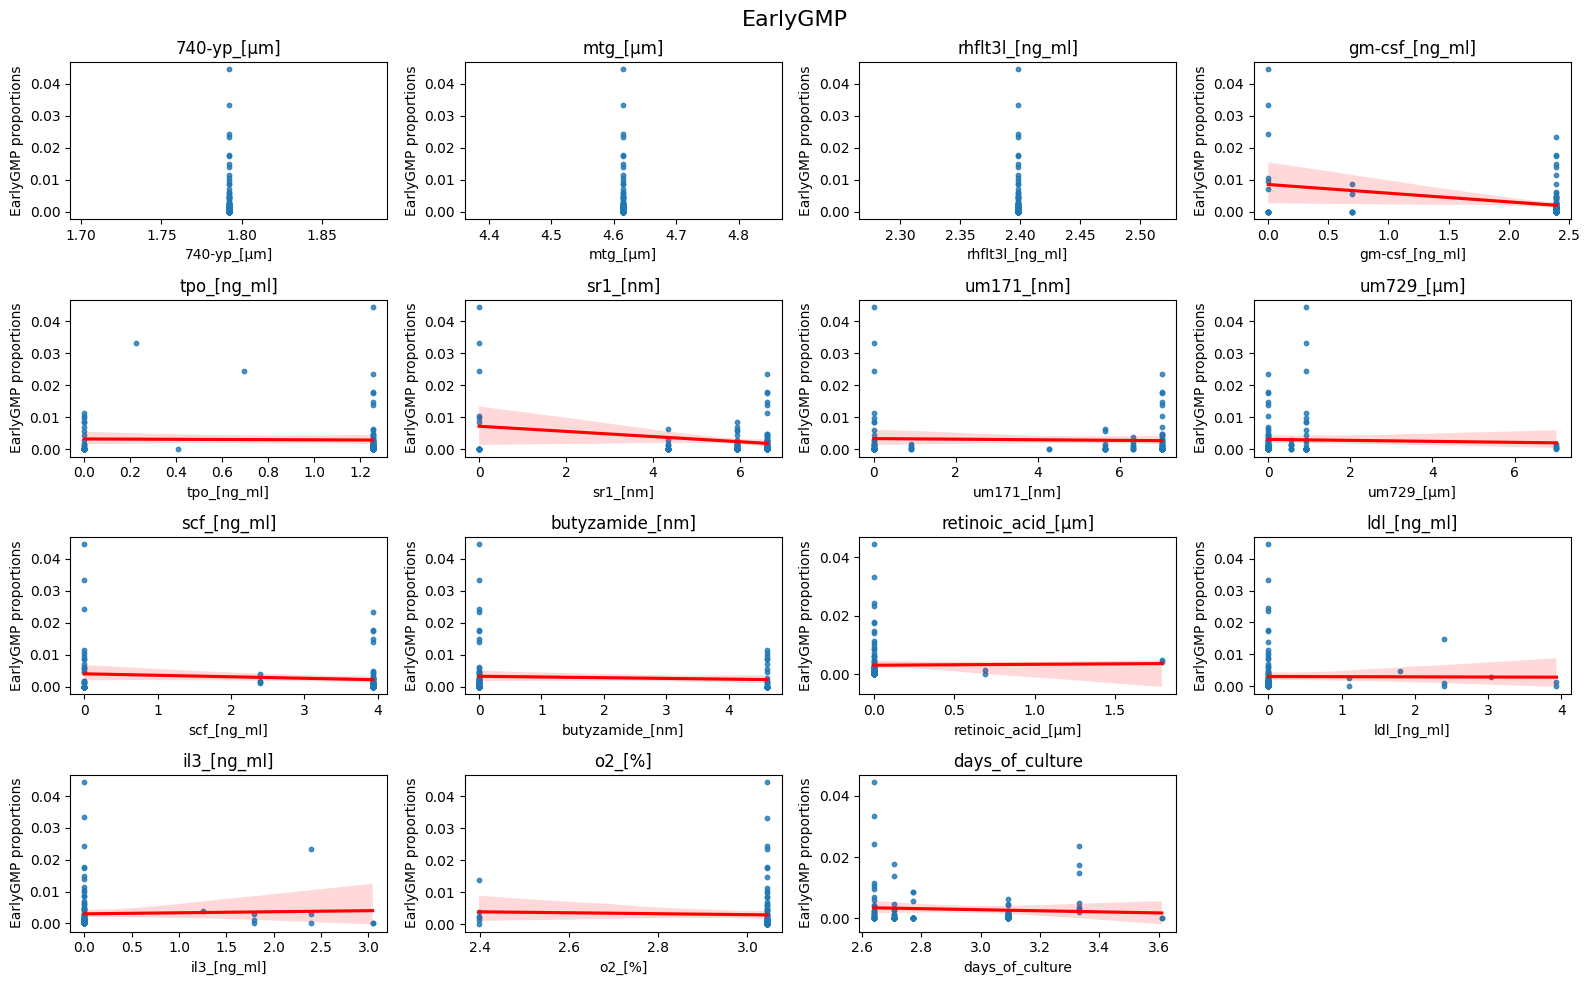

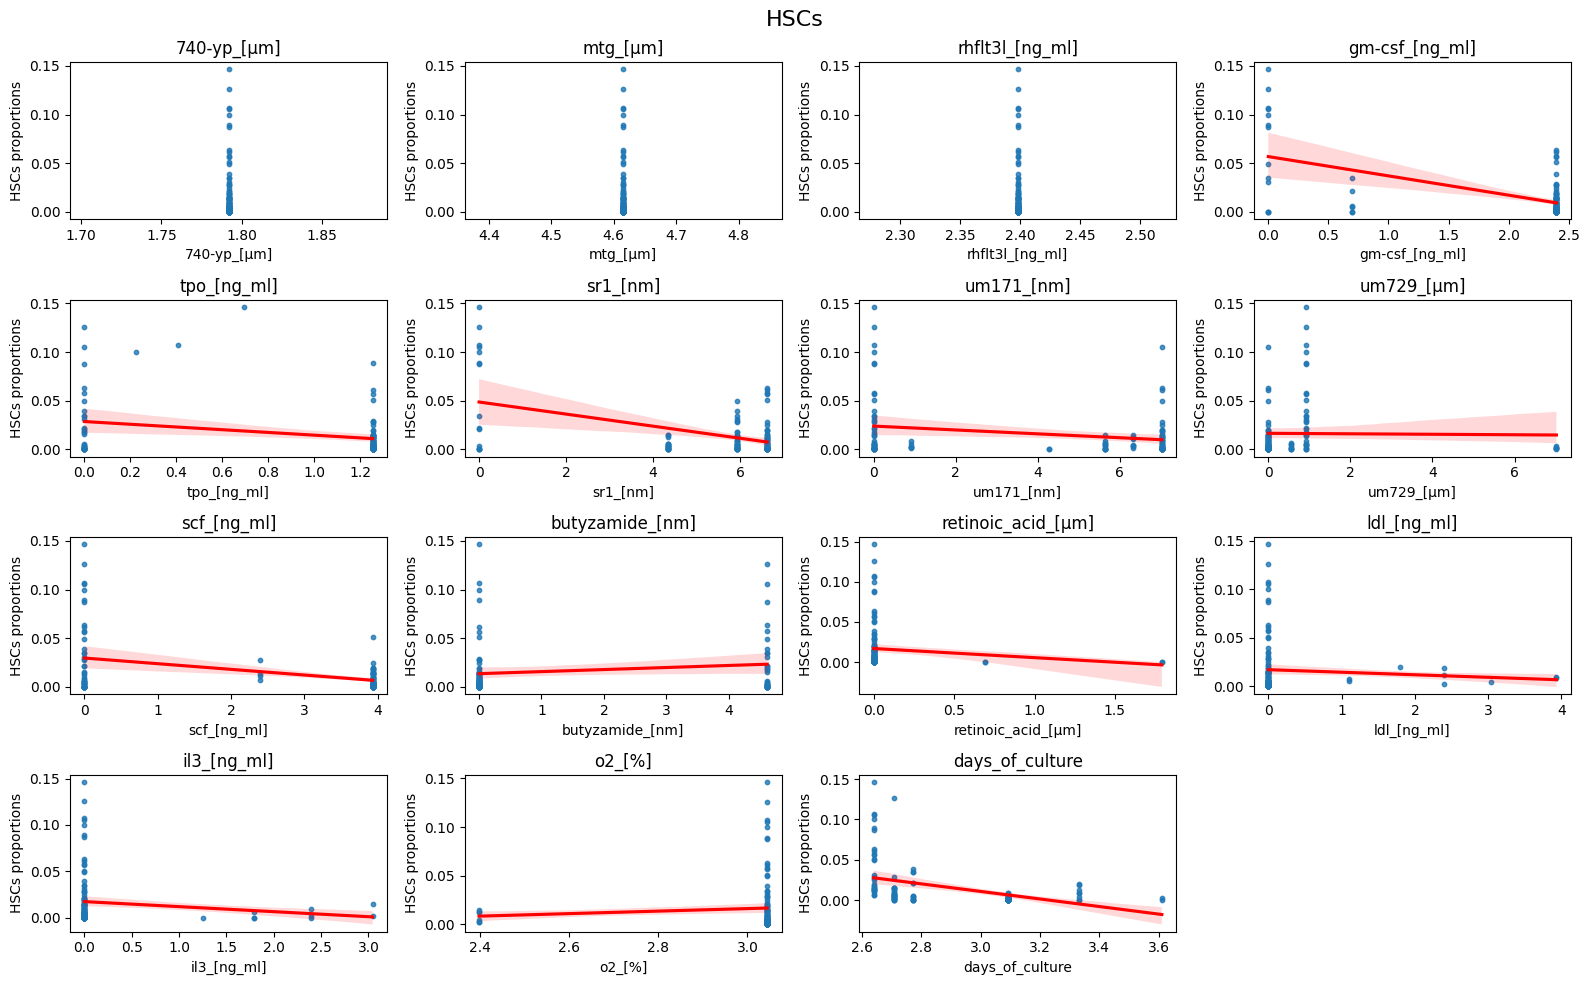

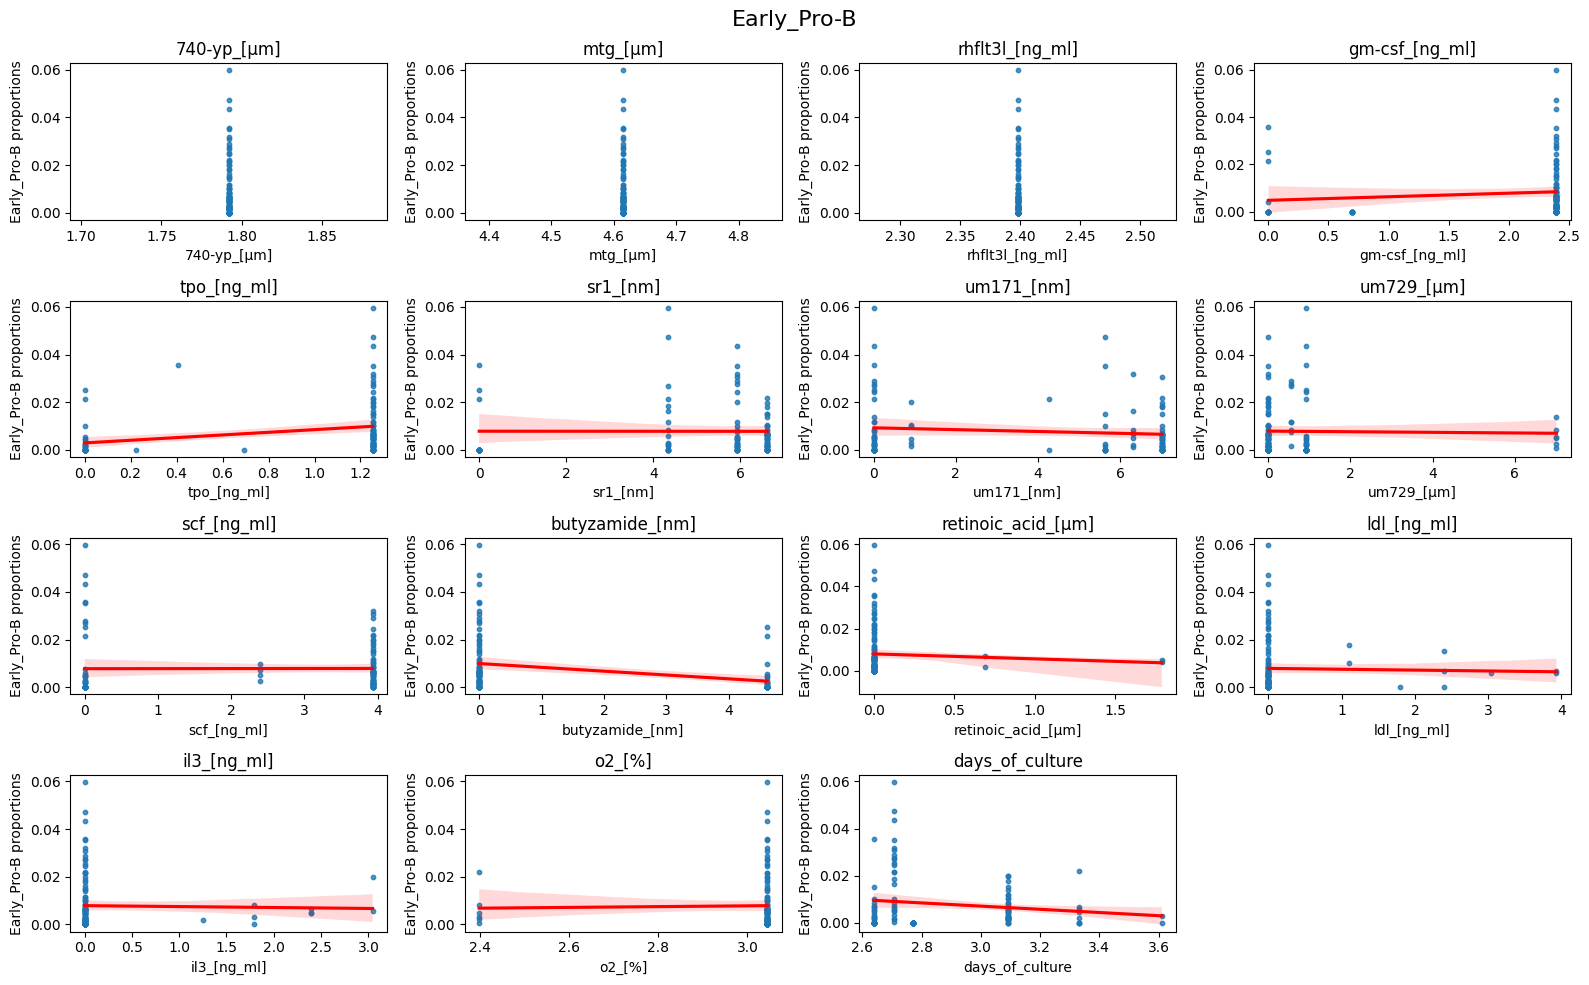

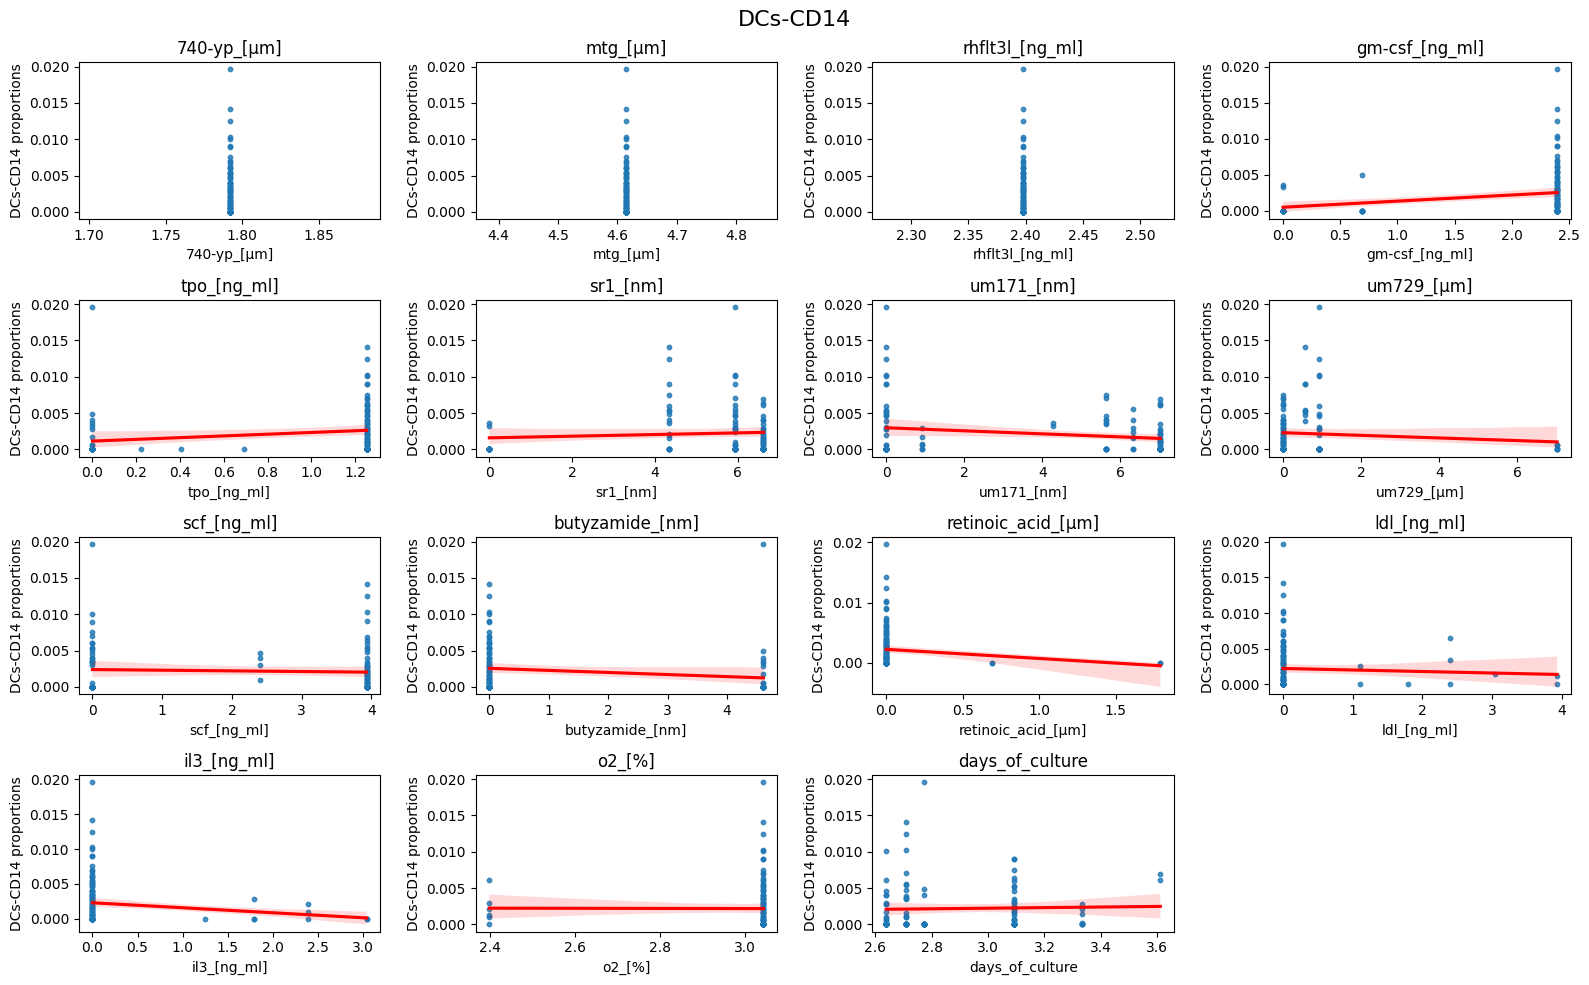

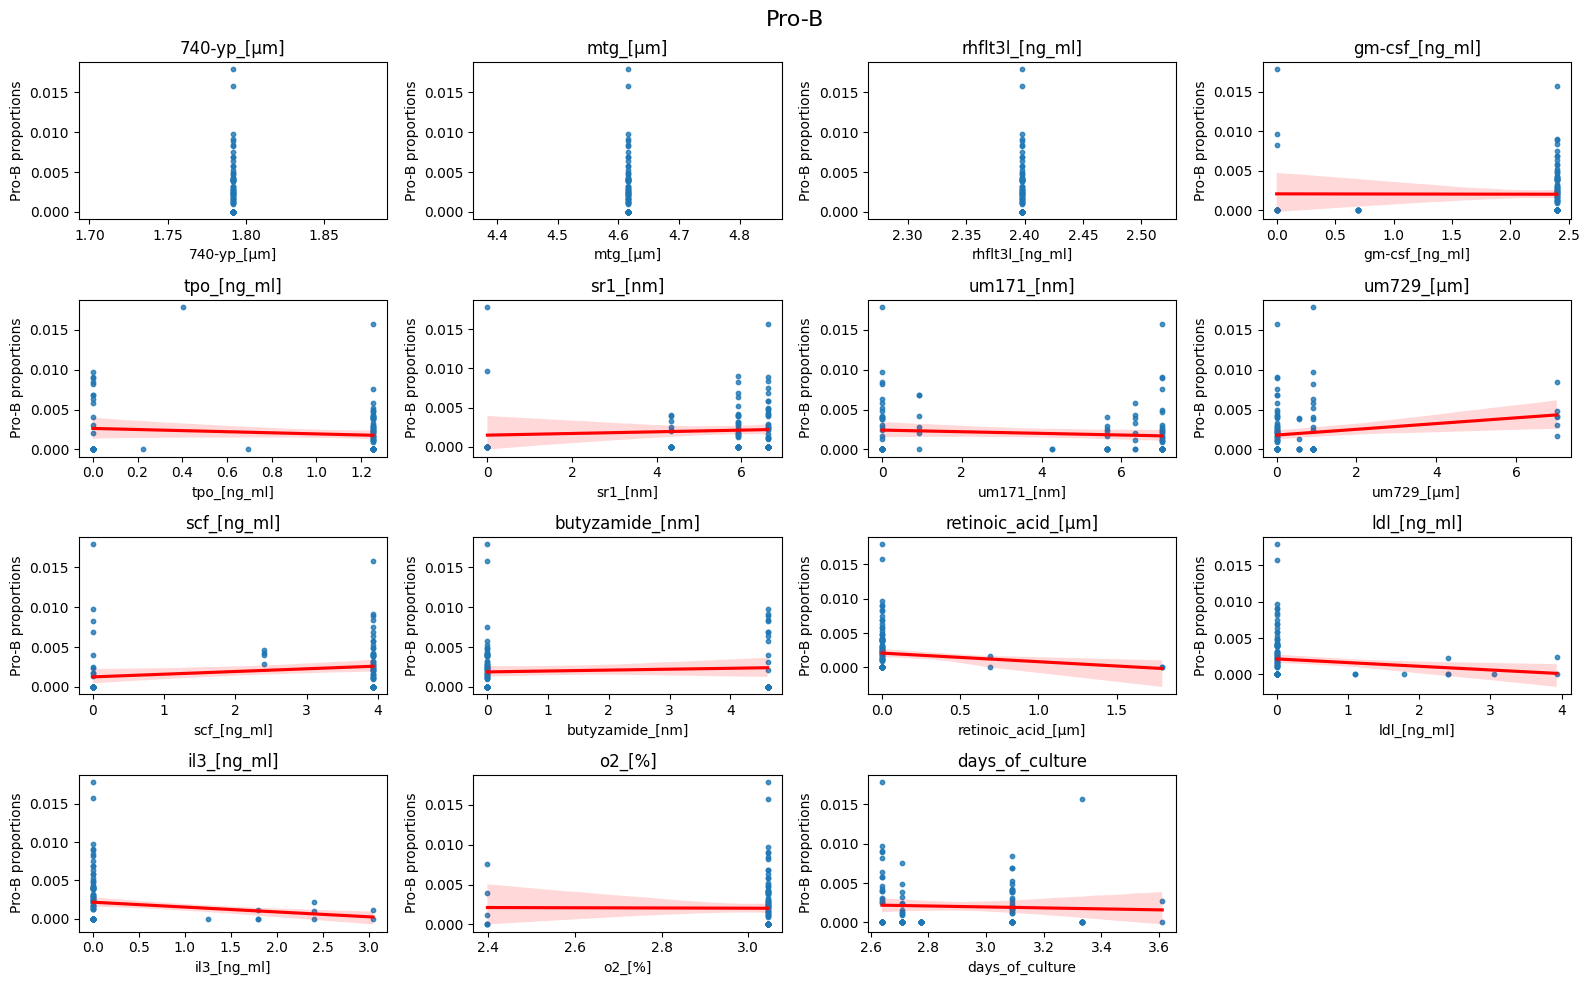

In [17]:
for cell_type in protocol_adata.obs.columns:

    to_plot_df = pd.DataFrame(protocol_adata.X)
    to_plot_df.columns = protocol_adata.var.index
    to_plot_df[f"{cell_type} proportions"] = np.array(protocol_adata.obs[cell_type])

    protocols = protocol_adata.var.index

    n_cols = 4
    n_rows = int(np.ceil(len(protocols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
    axes = axes.flatten()

    for i, protocol in enumerate(protocols):
        sns.regplot(
            data=to_plot_df,
            x=protocol,
            y=f"{cell_type} proportions",
            ax=axes[i],
            scatter_kws={"s": 10},
            line_kws={"color": "red"}
        )
        axes[i].set_title(protocol)

    for j in range(len(protocols), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"{cell_type}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [18]:
adata_argmax.obs.drop(["cell_type"], axis=1).max(0).sort_values(ascending=False)

CyclingProgenitor*      0.806867
CD49c-Myeloid           0.769759
MPP                     0.768421
GMP-Neutro              0.575758
GMP-Cycle               0.346032
EryPro                  0.344512
EosBasoMastPre          0.323171
pDCs/cDCs               0.289644
EosBasoMastPre_2        0.207965
MLP                     0.180307
MEP                     0.149206
HSCs                    0.146341
CD14-Mono               0.108565
MgkPro                  0.108197
GMP-Neutro/CD16-Mono    0.069697
Early_Pro-B             0.059701
EarlyGMP                0.044444
DCs-CD14                0.019608
Pro-B                   0.017857
dtype: float64

# Check distribution of proportions per cell type

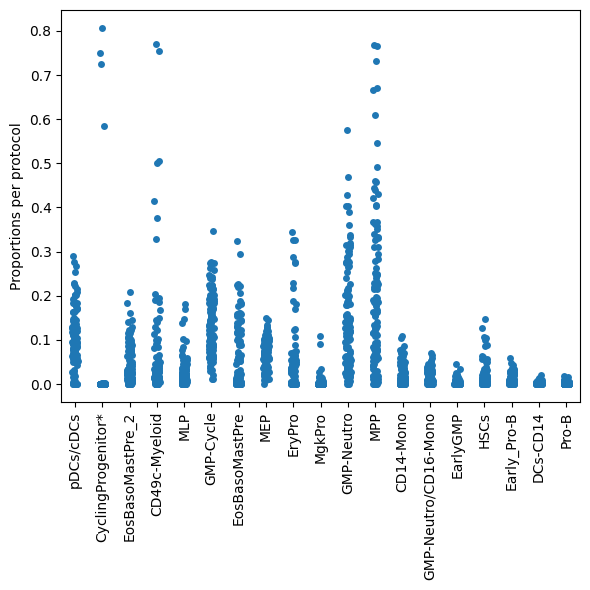

In [19]:
df = protocol_adata.obs.melt()

plt.figure(figsize=(6, 6))

sns.stripplot(
    data=df,
    x="variable",
    y="value",
    # showfliers=False  # cleaner look (optional)
)

plt.xticks(rotation=90)  # rotate labels
plt.xlabel("")
plt.ylabel("Proportions per protocol")
# plt.title("Proportions per protocols (103 unique protocols)", fontsize=14)

plt.tight_layout()
plt.show()

## Save the results

In [20]:
protocol_adata.obs.columns = [
    col.replace("/", "_") for col in protocol_adata.obs.columns
]

protocol_adata.write_h5ad("protocol_adata.h5ad")

## Check cell type overlaps 

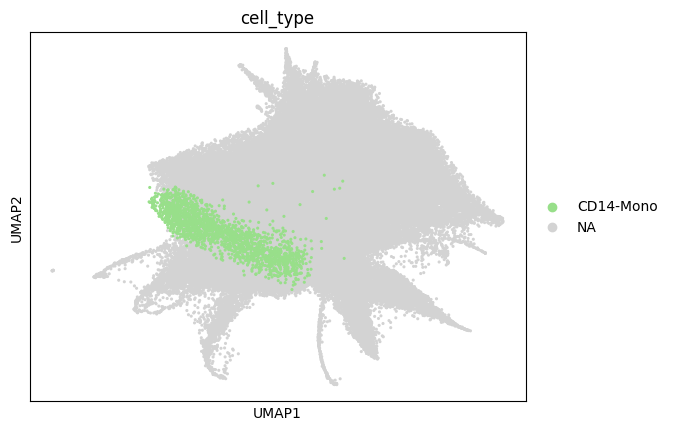

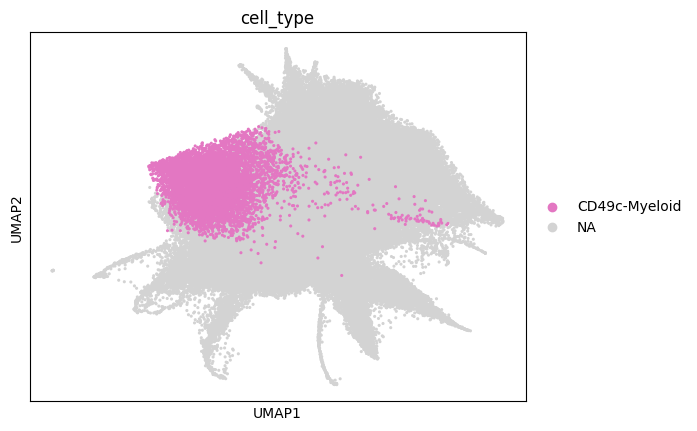

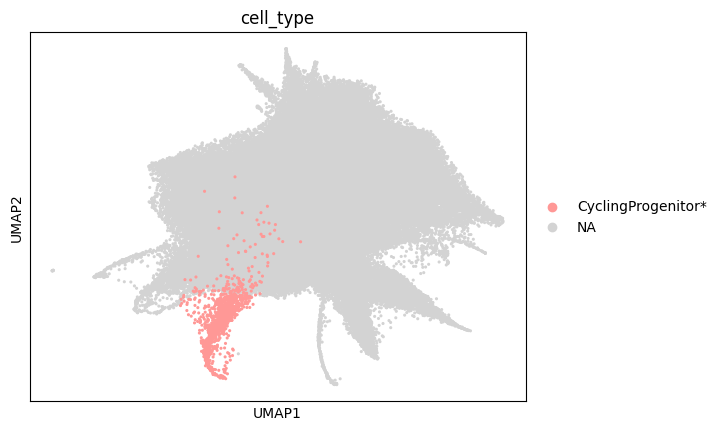

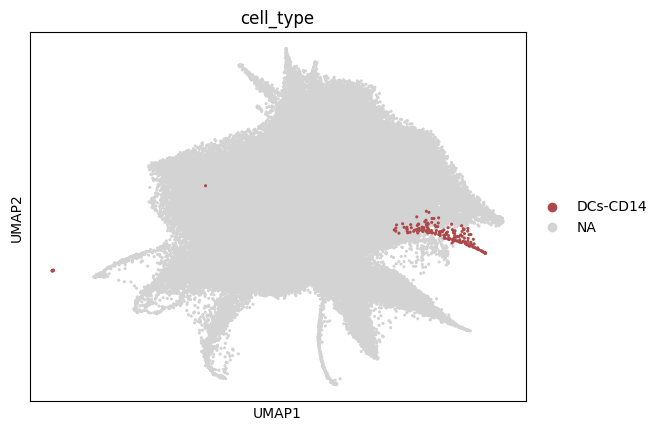

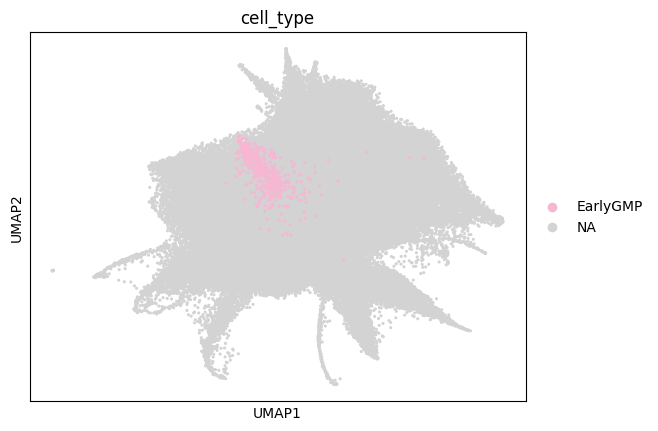

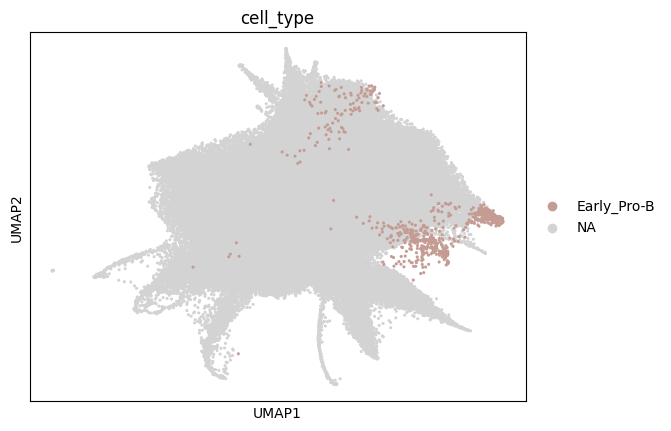

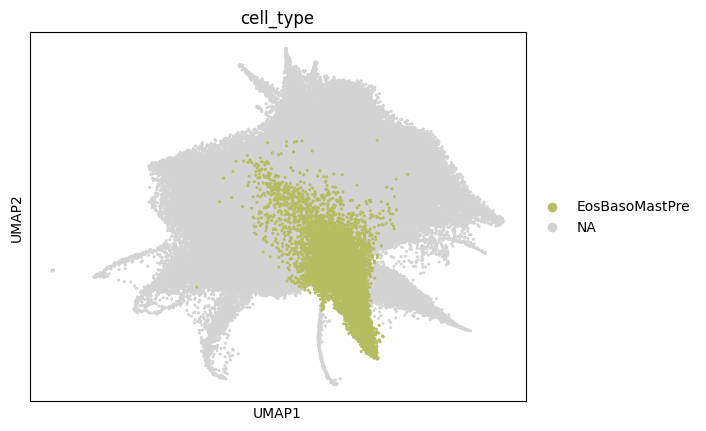

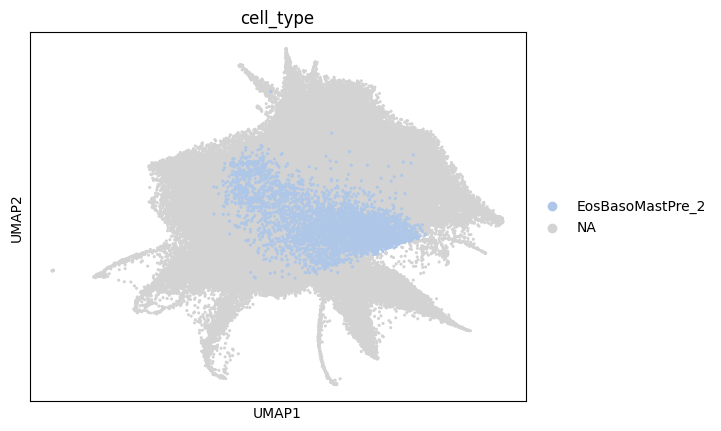

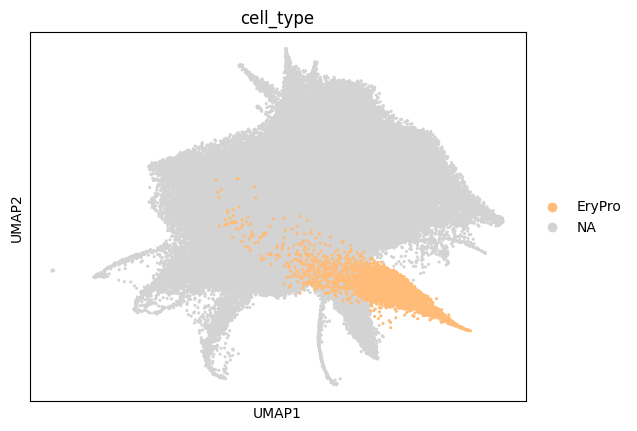

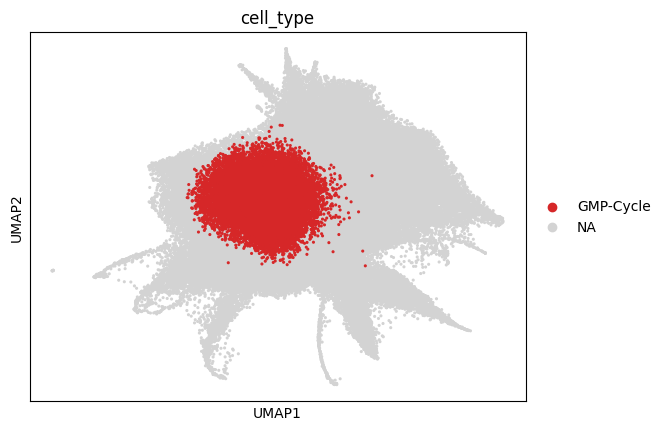

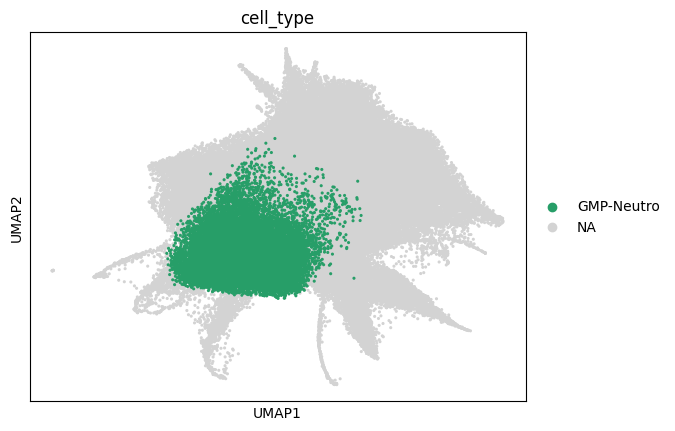

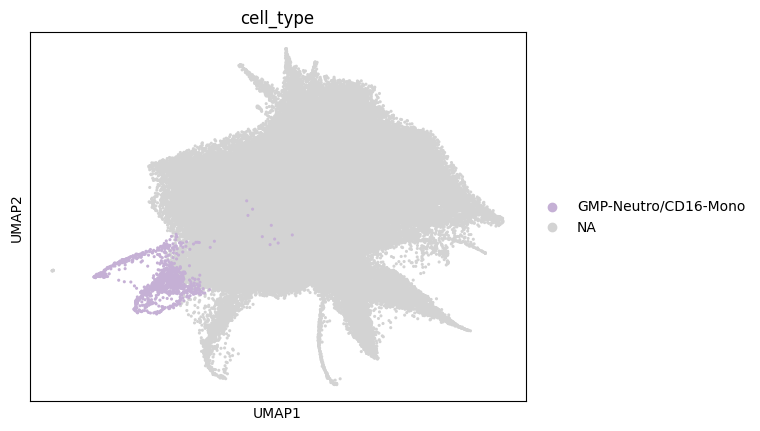

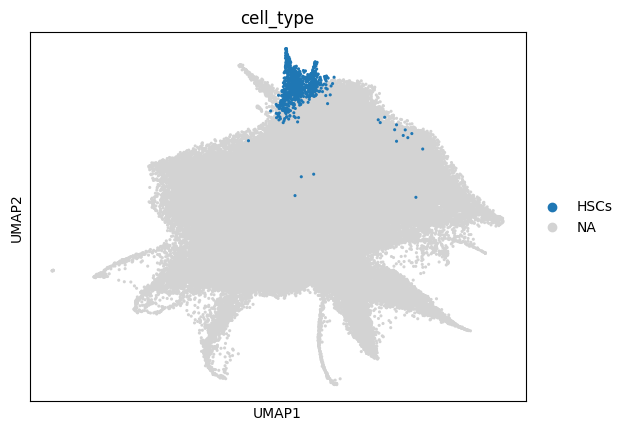

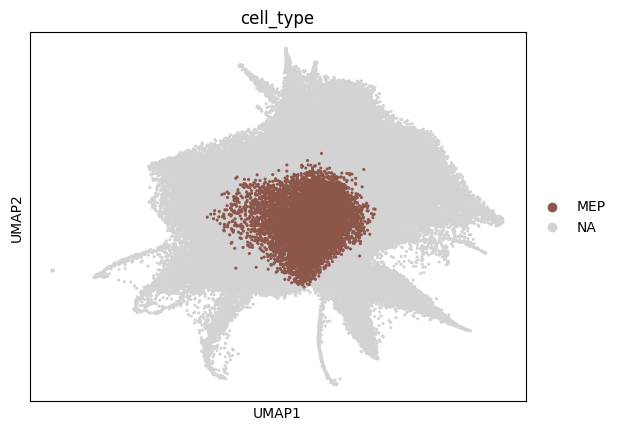

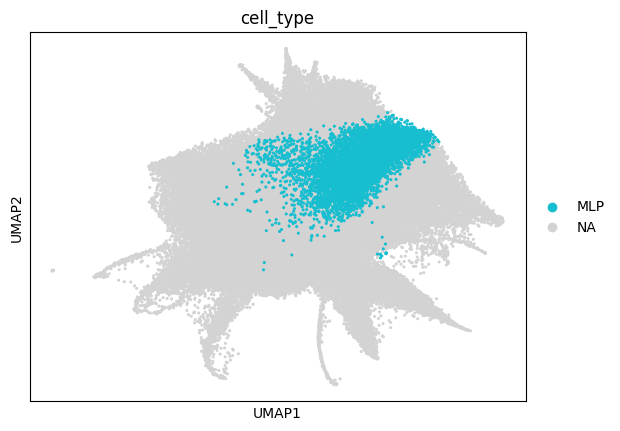

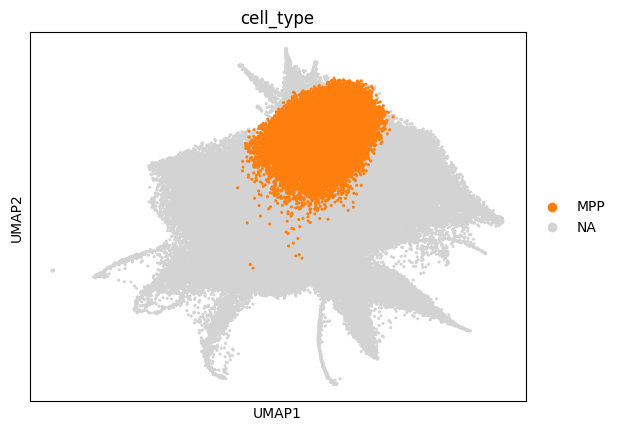

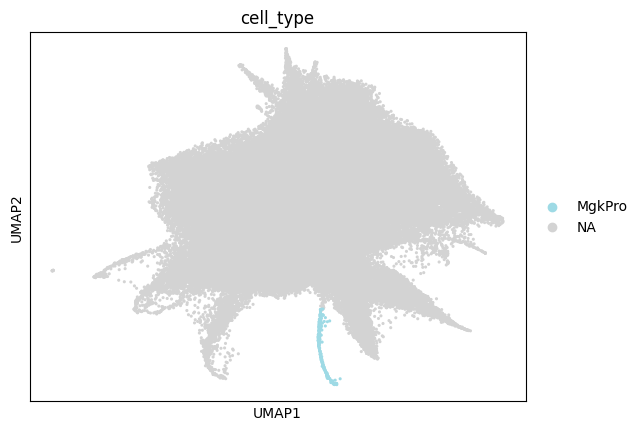

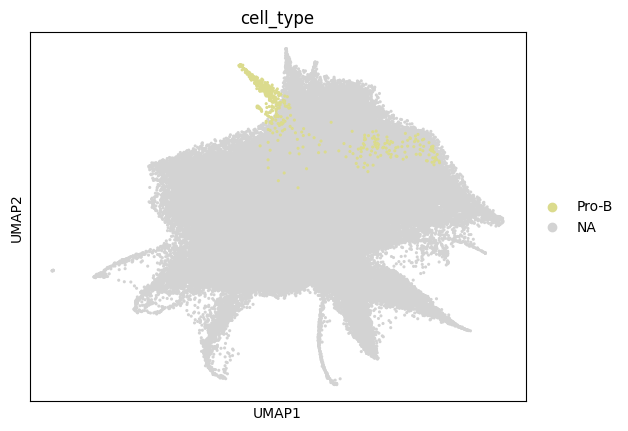

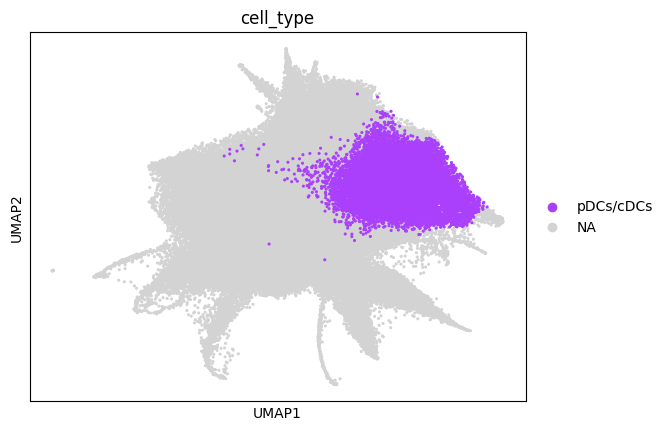

In [23]:
for cell_type in np.unique(adata.obs.cell_type):
    sc.pl.umap(
    adata,
        color="cell_type",
        s=20,
        groups=[cell_type]
    )

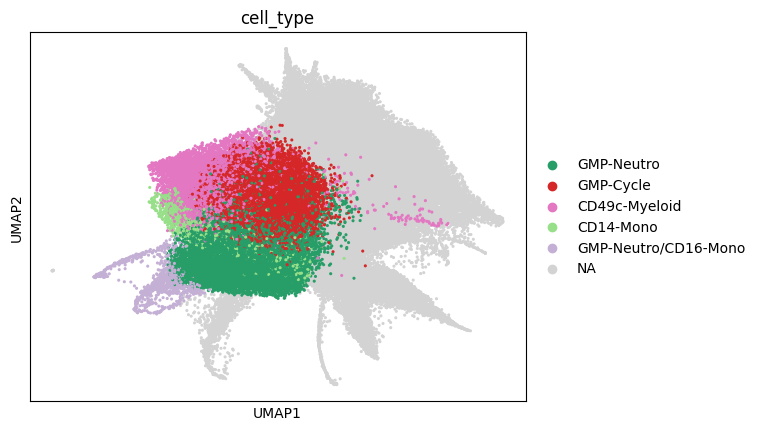

In [28]:
sc.pl.umap(
    adata,
    color="cell_type",
    s=20,
    groups=["CD14-Mono", 
            "CD49c-Myeloid",
            "GMP-Cycle",
            "GMP-Neutro", 
           "GMP-Neutro/CD16-Mono"]
)